# <center> 🧠 **Understand ADHD**
### <center>  👩🏻‍🔧    **By Rosy**

## 🎯 **Goals & Tasks:**

**1. Provide insights by means of Data.**

**2. Understand ADHD， particularly the differences in sypmtoms between women and men.** 

**3. Advance personalized medicine for neurodevelopmental disorders through an effective model.** 

**4. Given insights from statistical physics.** 

## ⚖️ **Measurements (Feature Variables):**

#### 1. **Questionnaires:** 
* **The Strength and Difficulties Questionnaire**

* **Alabama Parenting Questionnaire**

* **Barratt Simplified Measure of Social Status**

#### 2. **Clinical Measurements**: 
* **Edinburgh Handedness Inventory** 

* **Color Vision Test** 

#### 3. **Functional Connectivity Matrix** 

## 💡 **Target Variables:**

1. **ADHD Diagnosis (ADHD_Outcome)** 
2. **Biological Sex (Sex_F)**  

##  🗂️  ***Import Libraries***  

In [1]:
import os

import pandas as pd
import numpy as np
import networkx as nx 

import scipy.stats as stats 
import statsmodels.api as sm
import statsmodels.formula.api as smf  
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp 
import missingno as msno 
sns.set() 

from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score 

import warnings 
warnings.filterwarnings('ignore')            

In [2]:
os.listdir('/kaggle/input/adhd-train-data')   
os.listdir('/kaggle/input/adhd-solutions')  
os.listdir('/kaggle/input/functional-matrices')   

['TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv']

##  ⏳ ***Data Loading & Merging***  

In [3]:
df_quan = pd.read_excel('/kaggle/input/adhd-train-data/TRAIN_QUANTITATIVE .xlsx')   
df_cat = pd.read_excel('/kaggle/input/adhd-train-data/TRAIN_CATEGORICAL.xlsx') 
df_solu = pd.read_excel('/kaggle/input/adhd-solutions/TRAINING_SOLUTIONS.xlsx')   

In [4]:
df = df_quan.merge(df_cat, on='participant_id', how='inner')\
            .merge(df_solu, on='participant_id', how='inner') 

## 🔭 ***Data Overview***  

### 🔍 **1. Info & Dtype of Data**

In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   EHQ_EHQ_Total                     1200 non-null   float64
 2   ColorVision_CV_Score              1190 non-null   float64
 3   APQ_P_APQ_P_CP                    1201 non-null   float64
 4   APQ_P_APQ_P_ID                    1201 non-null   float64
 5   APQ_P_APQ_P_INV                   1201 non-null   float64
 6   APQ_P_APQ_P_OPD                   1201 non-null   float64
 7   APQ_P_APQ_P_PM                    1201 non-null   float64
 8   APQ_P_APQ_P_PP                    1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems          1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total        1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems        1204 non-null   float64
 12  SDQ_SD

### 🔍 **2.Take a Glimpse of Data**

In [6]:
df.head(5).T   

,0,1,2,3,4
participant_id,00aIpNTbG5uh,00fV0OyyoLfw,04X1eiS79T4B,05ocQutkURd6,06YUNBA9ZRLq
EHQ_EHQ_Total,100.0,92.27,86.67,93.34,0.0
ColorVision_CV_Score,13.0,14.0,14.0,14.0,14.0
APQ_P_APQ_P_CP,3.0,3.0,3.0,3.0,8.0
APQ_P_APQ_P_ID,15.0,12.0,21.0,11.0,12.0
APQ_P_APQ_P_INV,44.0,35.0,37.0,42.0,35.0
APQ_P_APQ_P_OPD,14.0,25.0,18.0,15.0,22.0
APQ_P_APQ_P_PM,20.0,28.0,26.0,20.0,12.0
APQ_P_APQ_P_PP,27.0,30.0,28.0,28.0,24.0
SDQ_SDQ_Conduct_Problems,3.0,5.0,3.0,0.0,6.0


### 🔍 **3. Descriptive Statistics**

In [7]:
round(df.describe(),3).T   

,count,mean,std,min,25%,50%,75%,max
EHQ_EHQ_Total,1200.0,59.515,49.745,-100.0,46.670,77.800,94.470,100.000
ColorVision_CV_Score,1190.0,13.419,2.113,0.0,14.000,14.000,14.000,14.000
APQ_P_APQ_P_CP,1201.0,3.819,1.330,2.0,3.000,3.000,4.000,12.000
APQ_P_APQ_P_ID,1201.0,13.337,3.594,5.0,11.000,13.000,16.000,28.000
APQ_P_APQ_P_INV,1201.0,39.768,4.873,23.0,36.000,40.000,43.000,50.000
APQ_P_APQ_P_OPD,1201.0,17.963,3.334,7.0,16.000,18.000,20.000,28.000
APQ_P_APQ_P_PM,1201.0,16.557,5.147,5.0,13.000,16.000,19.000,37.000
APQ_P_APQ_P_PP,1201.0,25.499,3.054,13.0,23.000,26.000,28.000,30.000
SDQ_SDQ_Conduct_Problems,1204.0,2.075,2.023,0.0,0.000,2.000,3.000,10.000
SDQ_SDQ_Difficulties_Total,1204.0,12.213,6.517,0.0,7.000,12.000,17.000,34.000


### 🔍 **4. Dimensions of DataFrame**

In [8]:
print(f'Rows: {df.shape[0]}')
print(f'Columns:{df.shape[1]}')    

Rows: 1213
Columns:30


### 🔍 **5. Check Duplicated & Missing & Unique Values** 

In [9]:
print(f'Duplicated: {df.duplicated().sum()}') 

Duplicated: 0


In [10]:
missing_counts = df.isnull().sum() 

missing_df = pd.DataFrame({
    'No. of Missing Values': missing_counts,
    '% of Missing Values' :  missing_counts / len(df)*100,
    'No. of Unique Values': df.nunique(),
    'Data Type': df.dtypes
})

missing_df.style.background_gradient('magma')    

,No. of Missing Values,% of Missing Values,No. of Unique Values,Data Type
participant_id,0,0.000000,1213,object
EHQ_EHQ_Total,13,1.071723,158,float64
ColorVision_CV_Score,23,1.896125,14,float64
APQ_P_APQ_P_CP,12,0.989283,10,float64
APQ_P_APQ_P_ID,12,0.989283,21,float64
APQ_P_APQ_P_INV,12,0.989283,26,float64
APQ_P_APQ_P_OPD,12,0.989283,21,float64
APQ_P_APQ_P_PM,12,0.989283,30,float64
APQ_P_APQ_P_PP,12,0.989283,17,float64
SDQ_SDQ_Conduct_Problems,9,0.741962,11,float64


### 🔍 **6. Define Target Variables** 

In [11]:
target_vars = ['ADHD_Outcome', 'Sex_F']    

### 🔍 **7. Looking for Overall Correlations**

In [12]:
df.drop('participant_id', axis=1, inplace=True)        

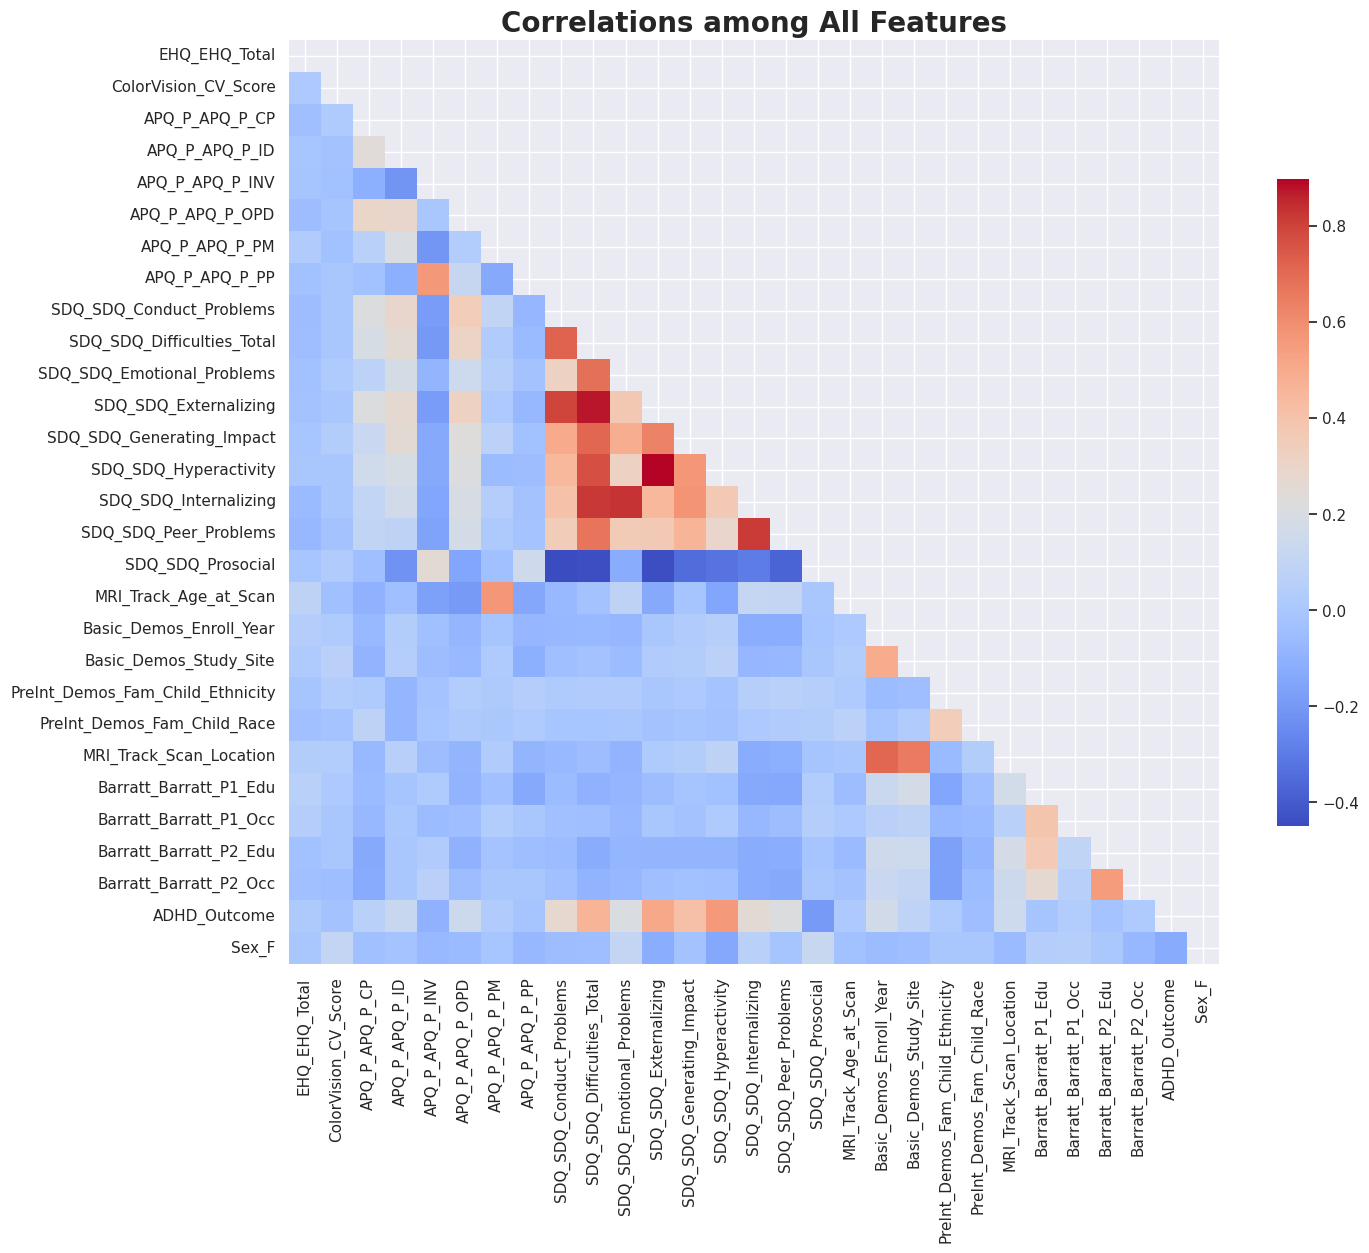

In [13]:
corr_matrix = df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig = plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, 
            mask=mask,
            cmap='coolwarm',
            cbar_kws={'shrink':0.7}) 


plt.title('Correlations among All Features', fontsize=20, fontweight='bold')  
plt.show()  

### 🔍 **8. Looking for Correlations between All Features and Target Variables** 

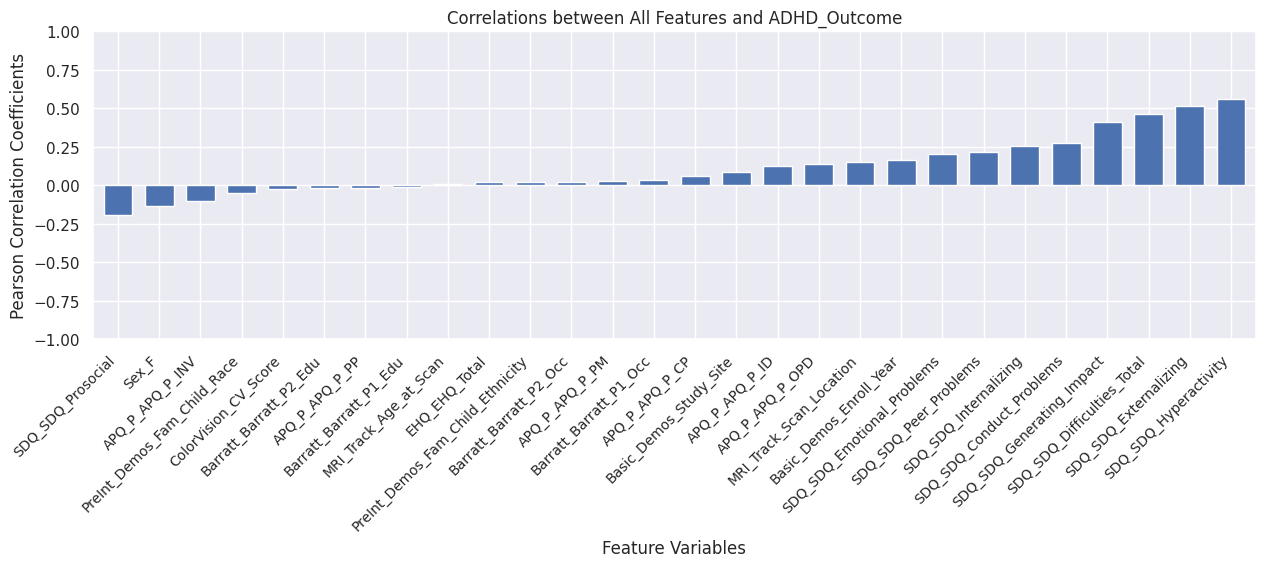

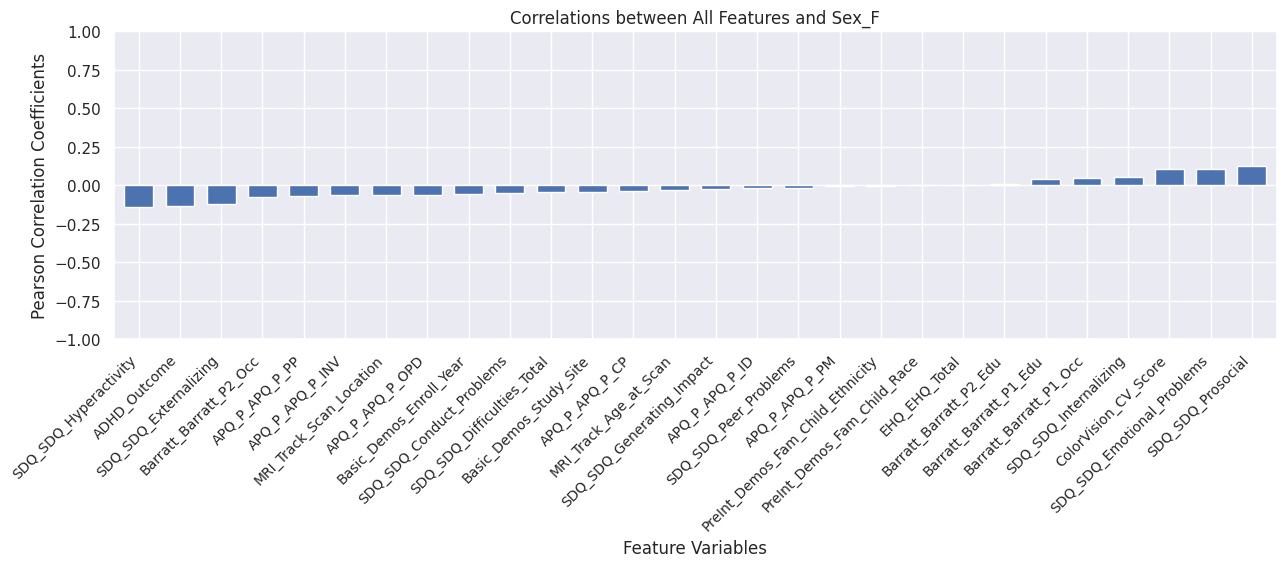

In [14]:
for var in target_vars: 
    correlations = df.corr()[var].drop(var).sort_values()   
    fig = plt.figure(figsize=(15,4)) 
    ax = correlations.plot(kind='bar',
                           width=0.7,
                           title= f'Correlations between All Features and {var}')  
    
    ax.set(ylim=[-1,1], 
           ylabel='Pearson Correlation Coefficients',
           xlabel='Feature Variables')
    
    ax.set_xticklabels(correlations.index,
                      rotation=45,
                      ha='right',
                      fontsize=10) 
    plt.show()    

##  🔨***Data Cleansing***  

### 🔍 **1. Visualization of Distribution & Correlations between Missing Values**

<Axes: >

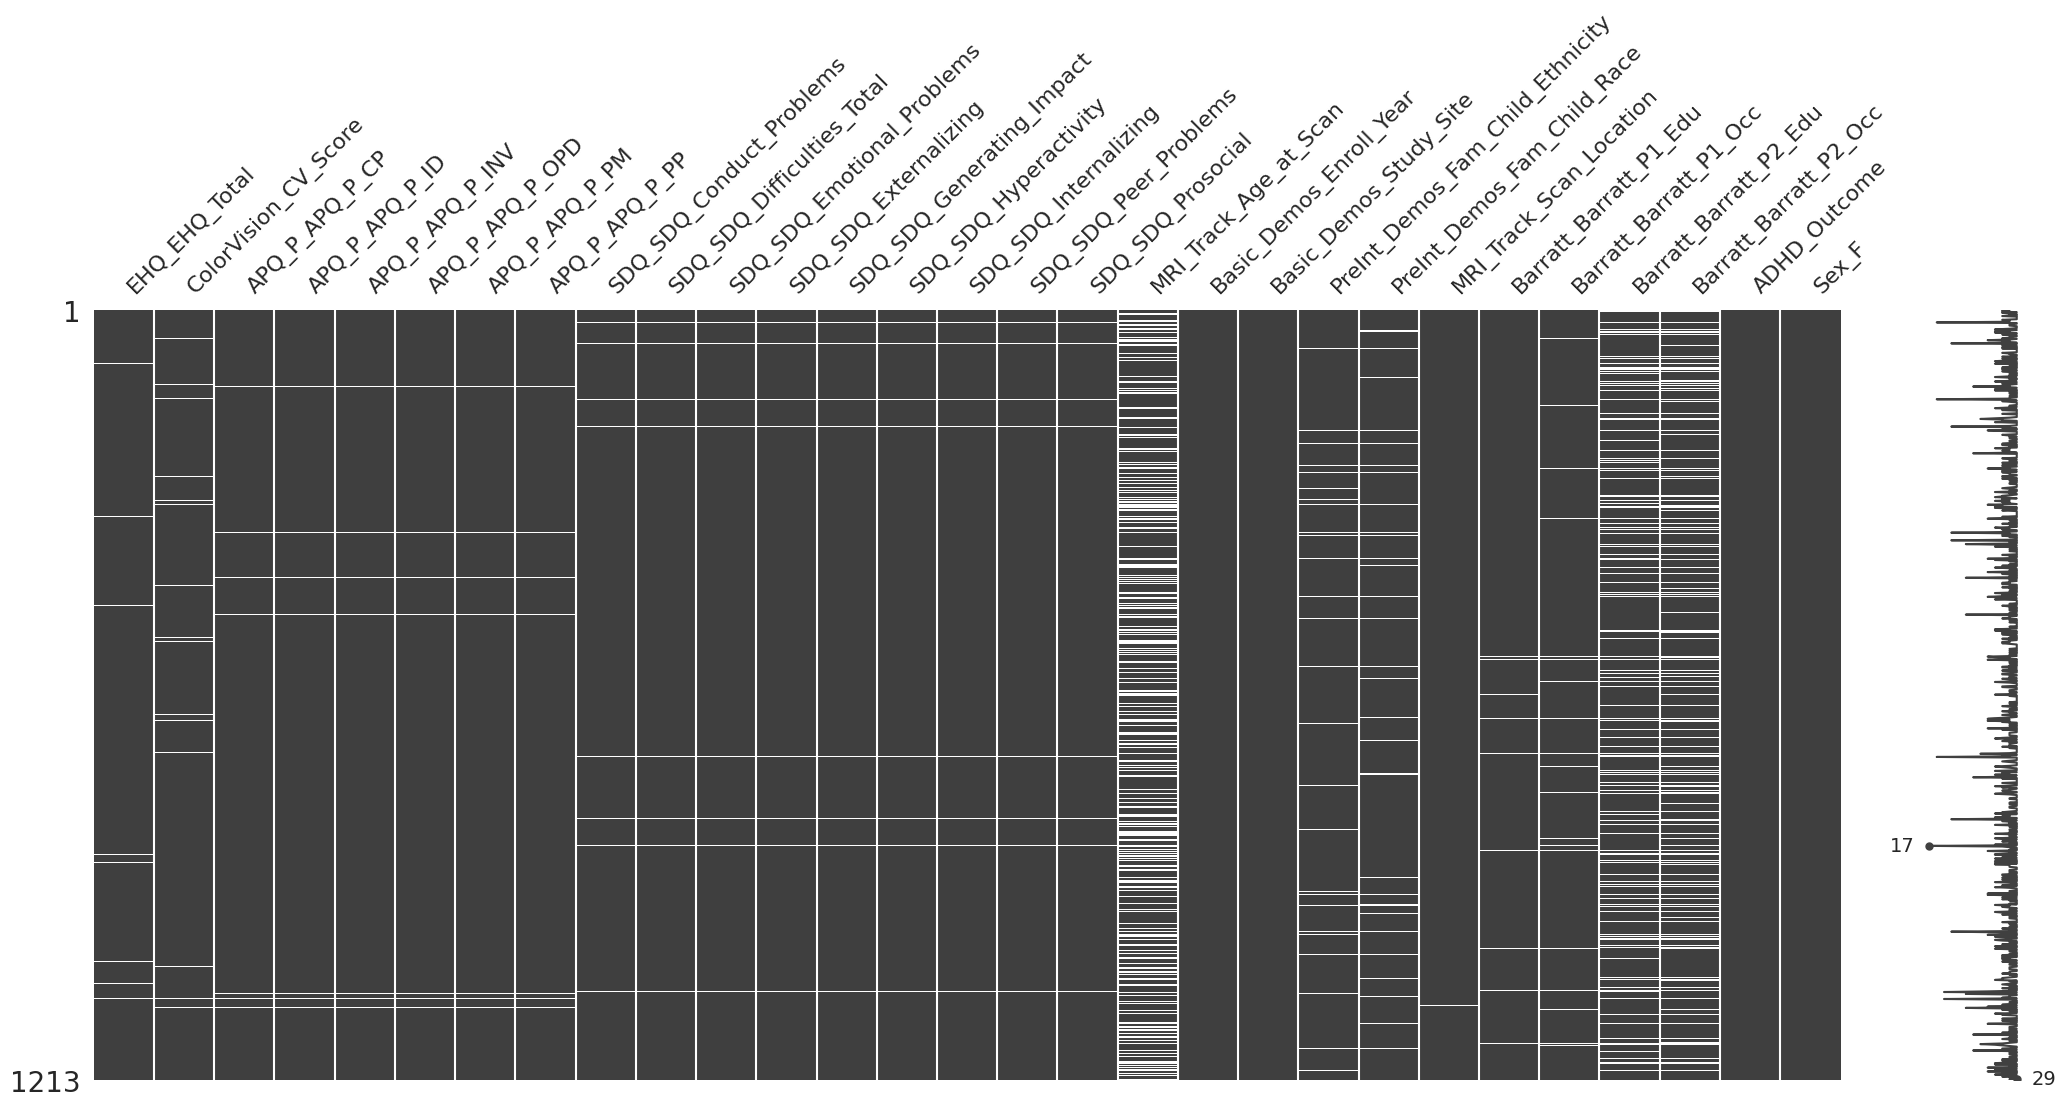

In [15]:
msno.matrix(df)    

<Axes: >

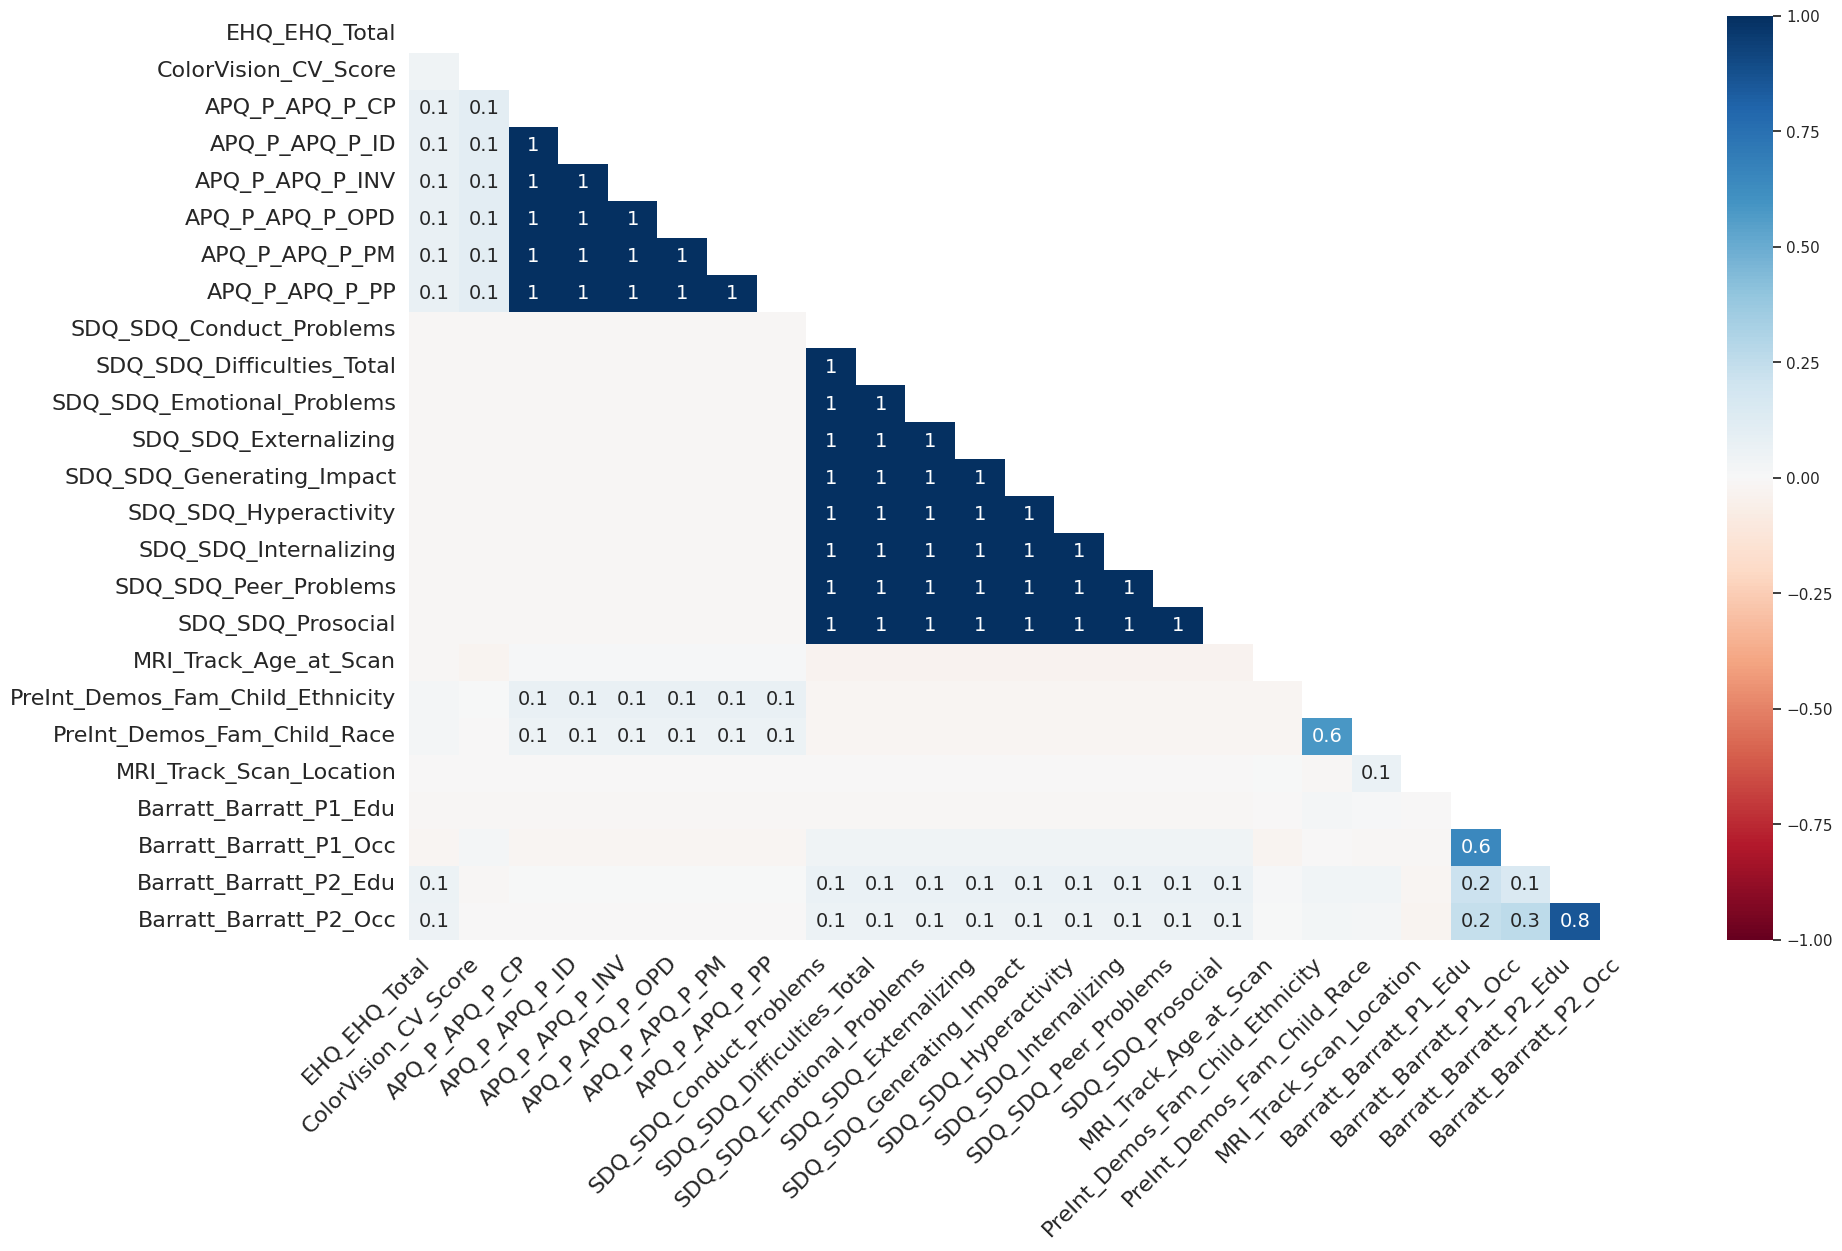

In [16]:
msno.heatmap(df)  

### 🔍 **2. Diagnosing Missing Mechanism in SDQ and APQ Questionnaire** 

### **2.1 Missingness in APQ & SDQ**

* **Regarding the missing data in the APQ & SDQ questionnaires, I observed that the correlation coefficients between the subscales in ADQ and SDQ are excatly 1.** 
* **This finding is unusual, and two potential explanations come to mind.**
  
  **1. Structual Missingness: It implies that some participants did not complete these scales.** 
  
  **2. Data Merging Issue: There may have been an error during the data merging process.(I have already checked the ruled out this possibility).**

In [17]:
SDQ_cols = [col for col in df.columns if col.startswith('SDQ')] 
APQ_cols = [col for col in df.columns if col.startswith('APQ')]    

In [18]:
SDQ_cols = [col for col in df.columns if col.startswith('SDQ')]
APQ_cols = [col for col in df.columns if col.startswith('APQ')] 

In [19]:
df[df[SDQ_cols].isnull().all(axis=1) | df[APQ_cols].isnull().all(axis=1)].T  

,19,52,120,140,183,350,362,368,421,479,...,735,801,843,978,1073,1076,1084,1098,1140,1165
EHQ_EHQ_Total,100.000000,33.350000,71.140000,100.000000,60.000000,100.0,77.8,-16.680000,8.94,13.34,...,60.000000,66.670000,73.34,81.140000,14.470000,33.350000,NaN,-100.000000,-20.000000,33.350000
ColorVision_CV_Score,14.000000,13.000000,14.000000,14.000000,13.000000,14.0,14.0,13.000000,14.00,14.00,...,14.000000,14.000000,14.00,14.000000,14.000000,14.000000,NaN,NaN,14.000000,13.000000
APQ_P_APQ_P_CP,4.000000,3.000000,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,3.000000,3.00,5.000000,7.000000,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_ID,18.000000,18.000000,NaN,9.000000,10.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,10.000000,10.00,15.000000,22.000000,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_INV,38.000000,45.000000,NaN,42.000000,40.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,47.000000,43.00,31.000000,36.000000,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_OPD,21.000000,22.000000,NaN,17.000000,17.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,15.000000,23.00,20.000000,23.000000,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_PM,25.000000,15.000000,NaN,14.000000,16.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,14.000000,24.00,21.000000,16.000000,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_PP,24.000000,27.000000,NaN,23.000000,23.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,27.000000,30.00,21.000000,27.000000,NaN,NaN,NaN,NaN,NaN
SDQ_SDQ_Conduct_Problems,NaN,NaN,2.000000,NaN,NaN,0.0,4.0,0.000000,3.00,3.00,...,3.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,3.000000,2.000000,5.000000
SDQ_SDQ_Difficulties_Total,NaN,NaN,7.000000,NaN,NaN,11.0,16.0,8.000000,6.00,6.00,...,6.000000,NaN,NaN,NaN,NaN,2.000000,12.000000,22.000000,13.000000,16.000000


### **2.2 Handling Missing Values in SDQ and ADQ**

* **Given the low missing rates(<1%), I decide to exclude the missing values.**  

In [20]:
empty_all = df[df[SDQ_cols].isnull().all(axis=1) | df[APQ_cols].isnull().all(axis=1)] 

In [21]:
df.drop(empty_all.index,inplace=True)   

### 🔍 **3. Multiple Imputation by Chained Equations (MICE)** 

#### **What is MICE:** 

**1. Build multiple data sets where missing values are replaced by different values --> each dataset provides a slightly different perspective of missing data** 

**2. Performs statistical analyses on all imputed datasets and combines the results to produce robust estimations.** 



#### **Why I Use MICE:** 

**1. Preserve the uncertainty of the missing values through multiple imputations.** 

**2. Reduces bias and inaccuracies compared to simple imputation methods.**

* ** 

#### **Drawing Parallels with Markov Property:** 

* **During the workflow of MICE, each regression model for imputing missing values is constructed conditionally solely on the current state of the dataset during the iterative process. --> demonstrated the Markov Property in its core mechanism.**

* ***Markov Property: "The memoryless property of a stochastic process, which means that its future evolution is independent of its history."*** 

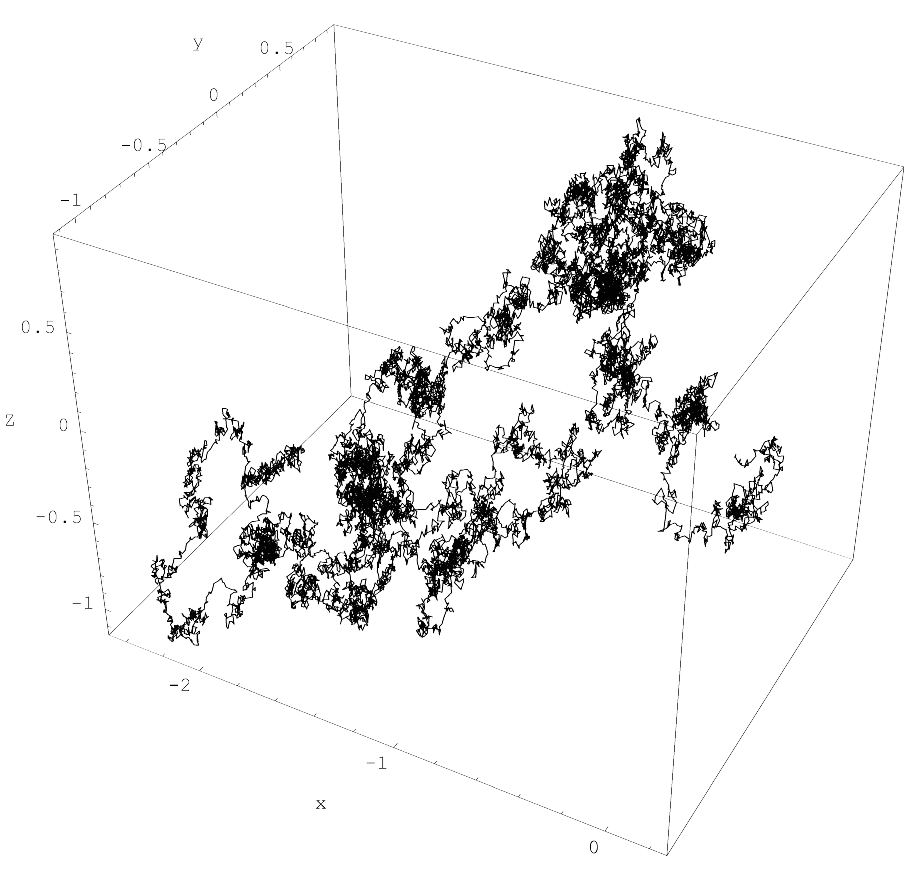
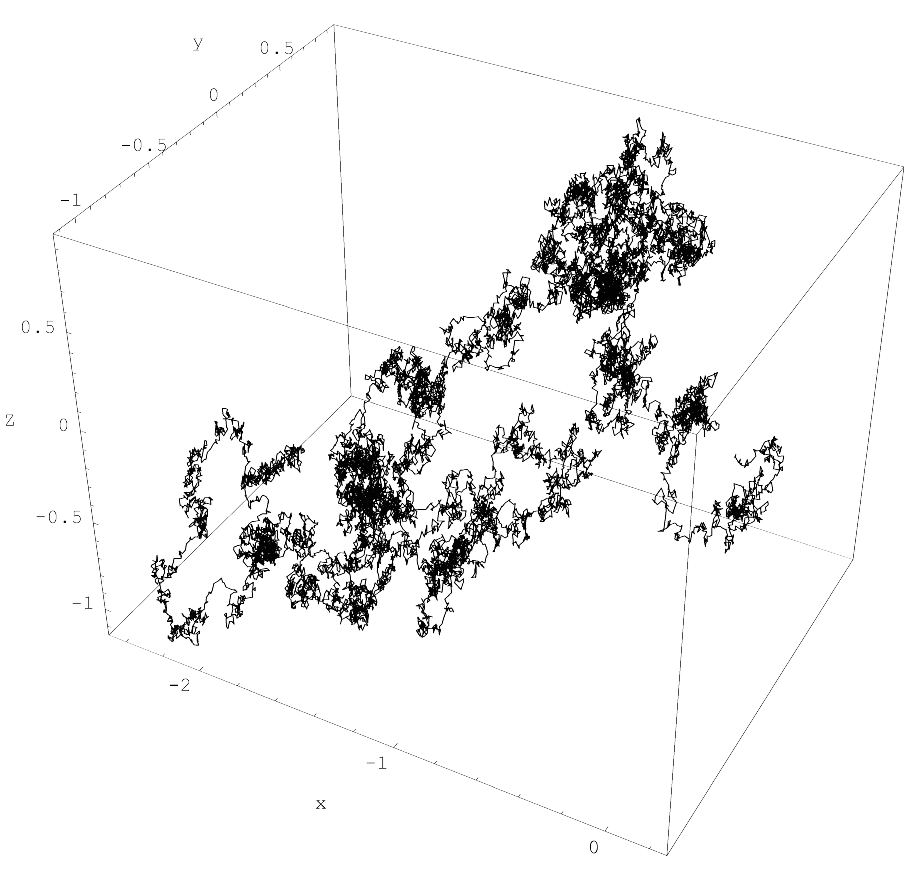

In [22]:
from statsmodels.imputation import mice
import statsmodels.api as sm 


# Build Multiple Data Sets: 
MI_df = mice.MICEData(df)


# Burn-in:
for _ in range(10):
    MI_df.update_all()

# Regression Analysis (based on OLS):  
fit = mice.MICE(model_formula= 'ADHD_Outcome ~ SDQ_SDQ_Externalizing + SDQ_SDQ_Difficulties_Total + SDQ_SDQ_Generating_Impact + SDQ_SDQ_Internalizing + SDQ_SDQ_Prosocial + APQ_P_APQ_P_ID + APQ_P_APQ_P_OPD + APQ_P_APQ_P_INV + Sex_F ',  
                model_class = sm.OLS,
                data=MI_df)

# Aggregate the Resulting Coefficients: 
MI_summ = fit.fit().summary()  
print(MI_summ)    

                                  Results: MICE
Method:                      MICE                  Sample size:              1192
Model:                       OLS                   Scale                     0.15
Dependent variable:          ADHD_Outcome          Num. imputations          10  
---------------------------------------------------------------------------------
                            Coef.  Std.Err.    t    P>|t|   [0.025  0.975]  FMI  
---------------------------------------------------------------------------------
Intercept                   0.2959   0.1313  2.2534 0.0242  0.0385  0.5533 0.0000
SDQ_SDQ_Externalizing       0.0334   0.0030 10.9977 0.0000  0.0275  0.0394 0.0000
SDQ_SDQ_Difficulties_Total  0.0162   0.0018  9.0914 0.0000  0.0127  0.0197 0.0000
SDQ_SDQ_Generating_Impact   0.0267   0.0058  4.5832 0.0000  0.0153  0.0381 0.0000
SDQ_SDQ_Internalizing      -0.0172   0.0031 -5.5067 0.0000 -0.0233 -0.0111 0.0000
SDQ_SDQ_Prosocial           0.0142   0.0063  2.268

In [23]:
# Select one dataset for the following analysis and data modeling: 

n_imputations = 5 
imputed_datasets = [] 


for _ in range(n_imputations):
    MI_df.update_all() 
    dataset_copy = MI_df.data.copy(deep=True) 
    imputed_datasets.append(dataset_copy) 


mi_df = imputed_datasets[0].copy()  

In [24]:
# check: 

mi_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   EHQ_EHQ_Total                     1192 non-null   float64
 1   ColorVision_CV_Score              1192 non-null   float64
 2   APQ_P_APQ_P_CP                    1192 non-null   float64
 3   APQ_P_APQ_P_ID                    1192 non-null   float64
 4   APQ_P_APQ_P_INV                   1192 non-null   float64
 5   APQ_P_APQ_P_OPD                   1192 non-null   float64
 6   APQ_P_APQ_P_PM                    1192 non-null   float64
 7   APQ_P_APQ_P_PP                    1192 non-null   float64
 8   SDQ_SDQ_Conduct_Problems          1192 non-null   float64
 9   SDQ_SDQ_Difficulties_Total        1192 non-null   float64
 10  SDQ_SDQ_Emotional_Problems        1192 non-null   float64
 11  SDQ_SDQ_Externalizing             1192 non-null   float64
 12  SDQ_SD

In [25]:
# check: 

mi_df.sample(5).T

,242,308,1007,129,527
EHQ_EHQ_Total,53.400000,93.340000,-100.00000,100.000000,100.000000
ColorVision_CV_Score,14.000000,14.000000,14.00000,14.000000,14.000000
APQ_P_APQ_P_CP,3.000000,3.000000,4.00000,3.000000,4.000000
APQ_P_APQ_P_ID,8.000000,15.000000,18.00000,8.000000,18.000000
APQ_P_APQ_P_INV,42.000000,35.000000,44.00000,41.000000,43.000000
APQ_P_APQ_P_OPD,20.000000,12.000000,22.00000,17.000000,22.000000
APQ_P_APQ_P_PM,37.000000,14.000000,11.00000,10.000000,12.000000
APQ_P_APQ_P_PP,30.000000,25.000000,27.00000,26.000000,27.000000
SDQ_SDQ_Conduct_Problems,1.000000,0.000000,2.00000,0.000000,4.000000
SDQ_SDQ_Difficulties_Total,5.000000,15.000000,21.00000,3.000000,19.000000


# 🎥   ***Data Visualization***    


### **1️⃣ Distribution of ADHD & Control Group**   

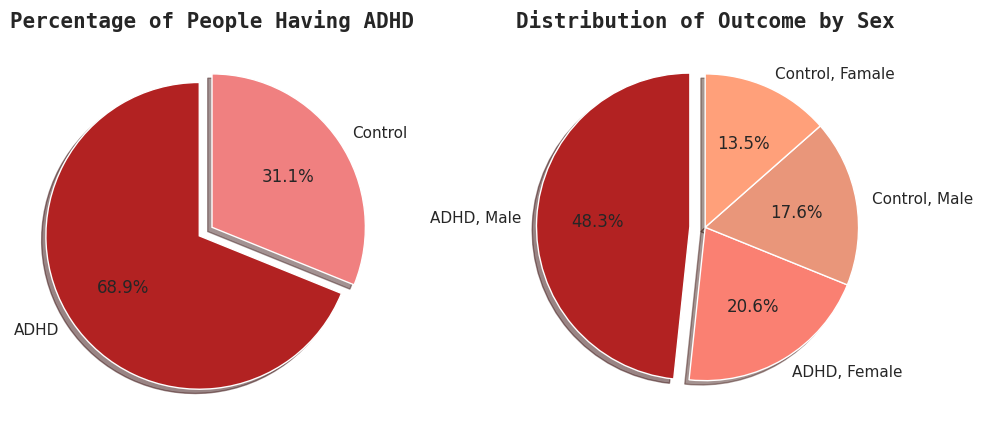

In [26]:
label_map1 = { 0:'Control',1: 'ADHD'} 

label_map2 = {
    (0,0) : 'Control, Male',
    (0,1) : 'Control, Famale',
    (1,0) : 'ADHD, Male',
    (1,1) :  'ADHD, Female' 
            }  

counts1 = mi_df['ADHD_Outcome'].value_counts() 
counts2 = mi_df[['ADHD_Outcome','Sex_F']].value_counts() 


custom_labels1 = [label_map1[idx] for idx in counts1.index]
custom_labels2 = [label_map2[idx] for idx in counts2.index]  


color_map1 = ['firebrick','LightCoral'] 
color_map2 = ['firebrick','Salmon','DarkSalmon','LightSalmon'] 




combined_group = [
    {'data': counts1, 'labels': custom_labels1, 'color': color_map1, 'explode': [0.1,0] , 'title': 'Percentage of People Having ADHD'},
    {'data': counts2, 'labels': custom_labels2, 'color': color_map2, 'explode': [0.1,0 ,0,0] , 'title': 'Distribution of Outcome by Sex'} 
]


fig,axes = plt.subplots(1,2, figsize=(10,7)) 

for i, group in enumerate(combined_group):
    group['data'].plot(kind='pie',
                       autopct='%1.1f%%',
                       startangle=90,
                       explode = group['explode'], 
                       labels = group['labels'],
                       colors = group['color'],
                       shadow=True, 
                       ax = axes[i]
                     ) 
    axes[i].set_ylabel('')
    axes[i].set_title(group['title'],
                      fontsize=15,
                      fontweight='bold',
                      fontfamily = 'monospace')  
    

plt.tight_layout()                                                                        
plt.show()     

#### **📝 Note:**

* **The dataset exhibited class imbalance.**
  
* **In the ADHD group, the diagnosis rate was significantly higher in males compare to females.**

 ####  2️⃣ ***SDQ(means) & APQ(means) by ADHD Outcome***  

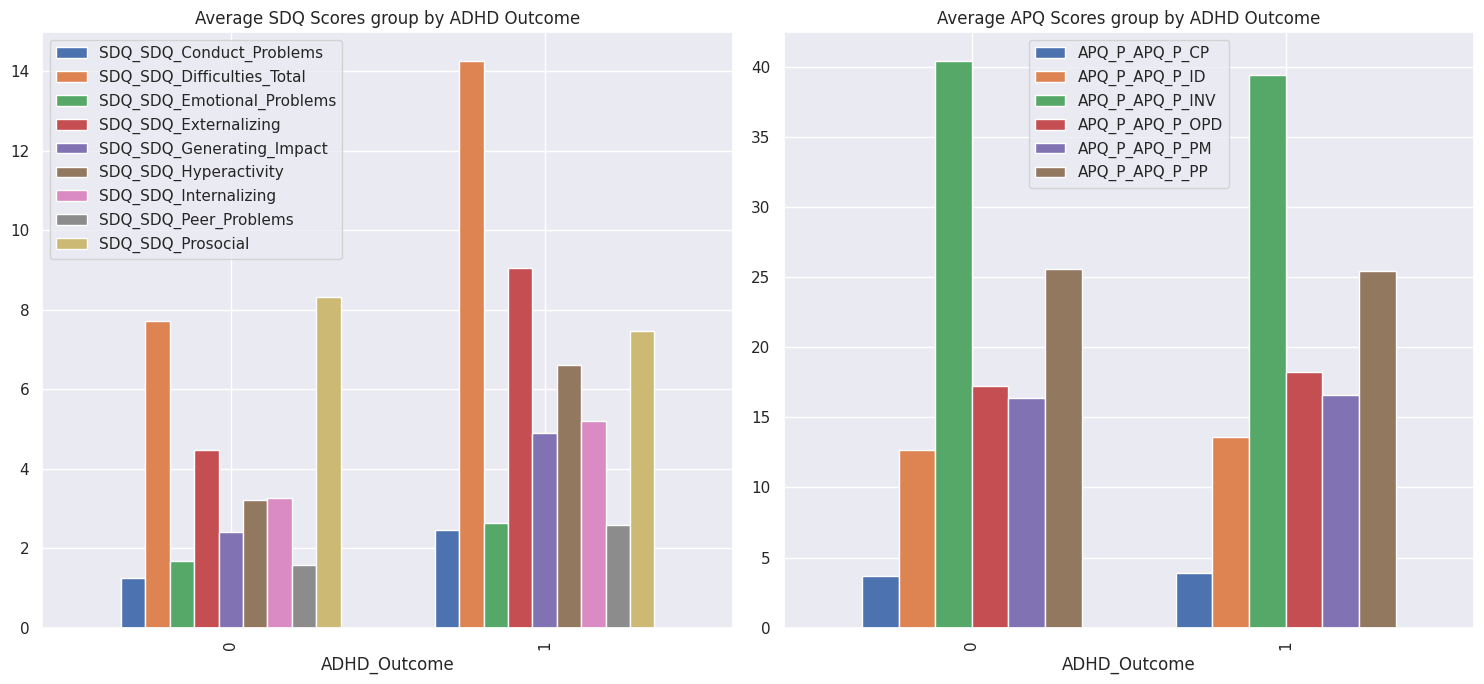

In [27]:
combinded_groups = [
    {'cols': SDQ_cols, 'title': 'SDQ Scores'}, 
    {'cols': APQ_cols, 'title': 'APQ Scores'}
 ]

fig, axes = plt.subplots(1,2, figsize=(15,7)) 

for i, group in enumerate(combinded_groups): 
    mi_df.groupby(target_vars[0])[group['cols']].mean().plot(
        kind='bar',
        width=0.7,
        ax=axes[i],
        title = f'Average {group["title"]} group by ADHD Outcome'
    ) 

    plt.legend() 
    
plt.tight_layout()         
plt.show()  

####  3️⃣ ***Barplot of Average SDQ Scores by ADHD Outcome & Boxplot by Outcome and Sex***   

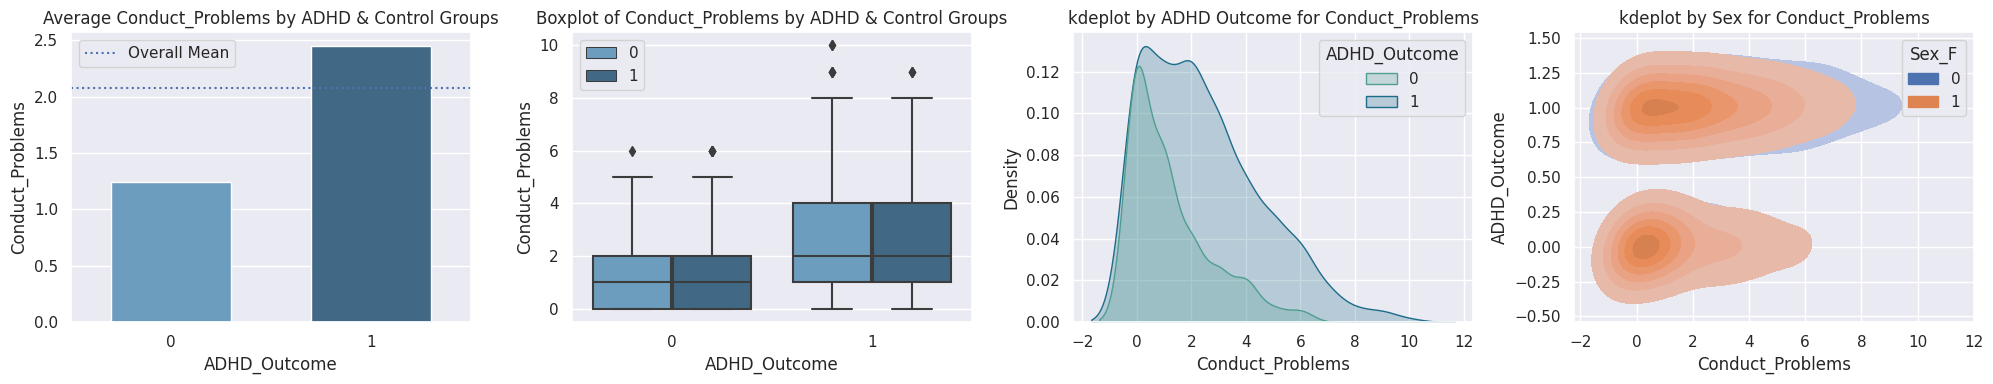

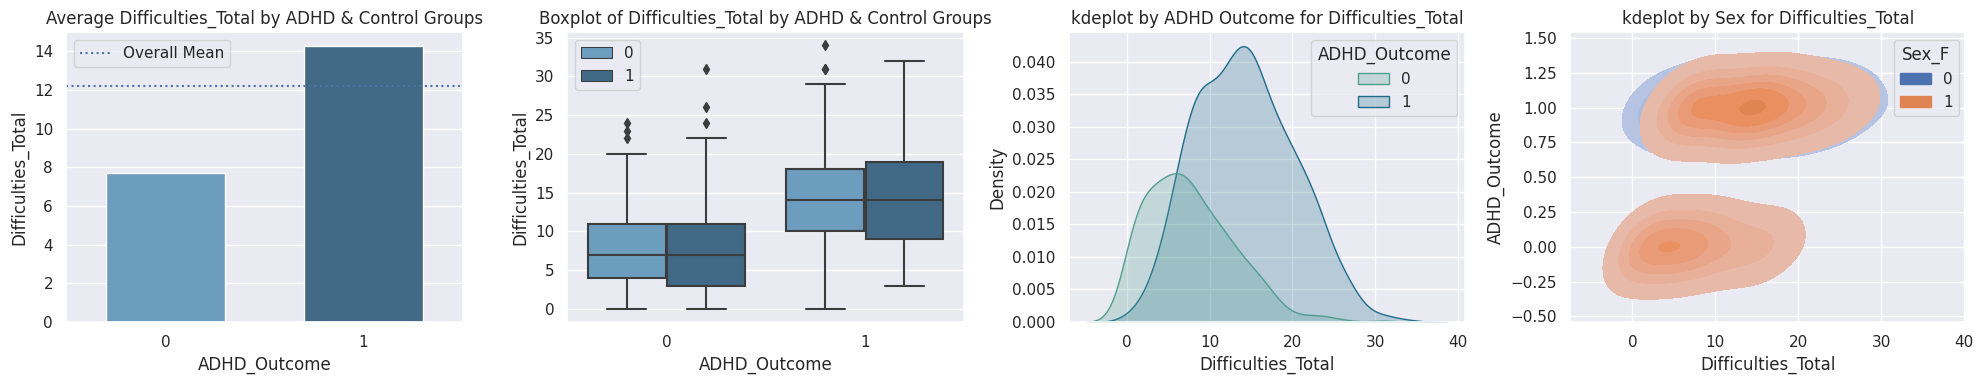

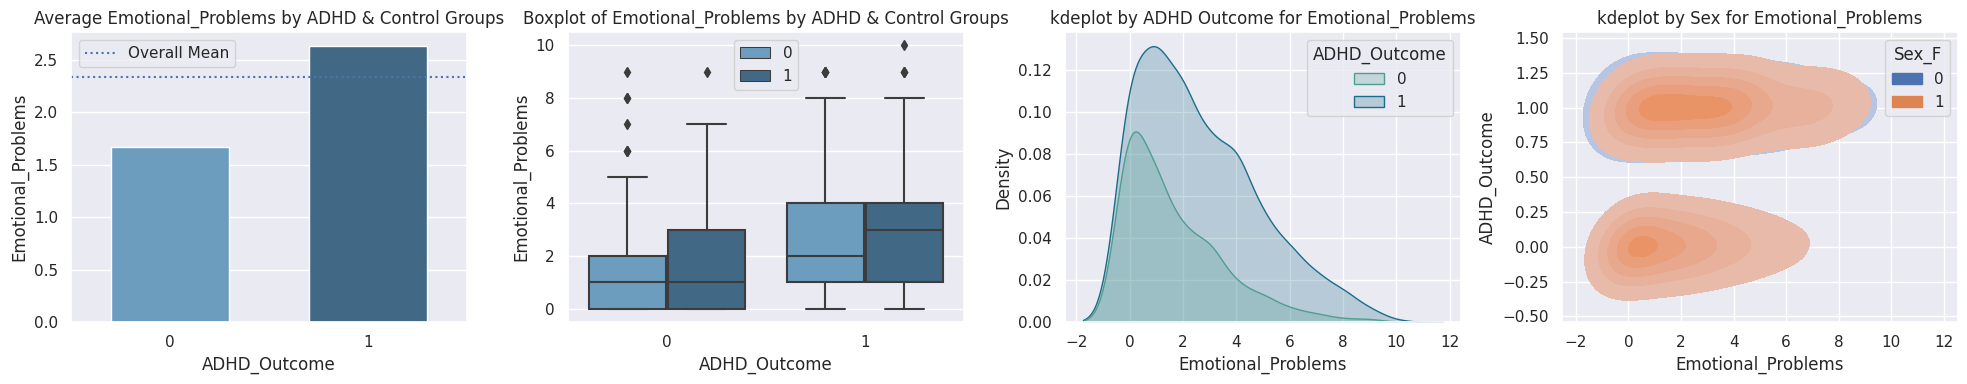

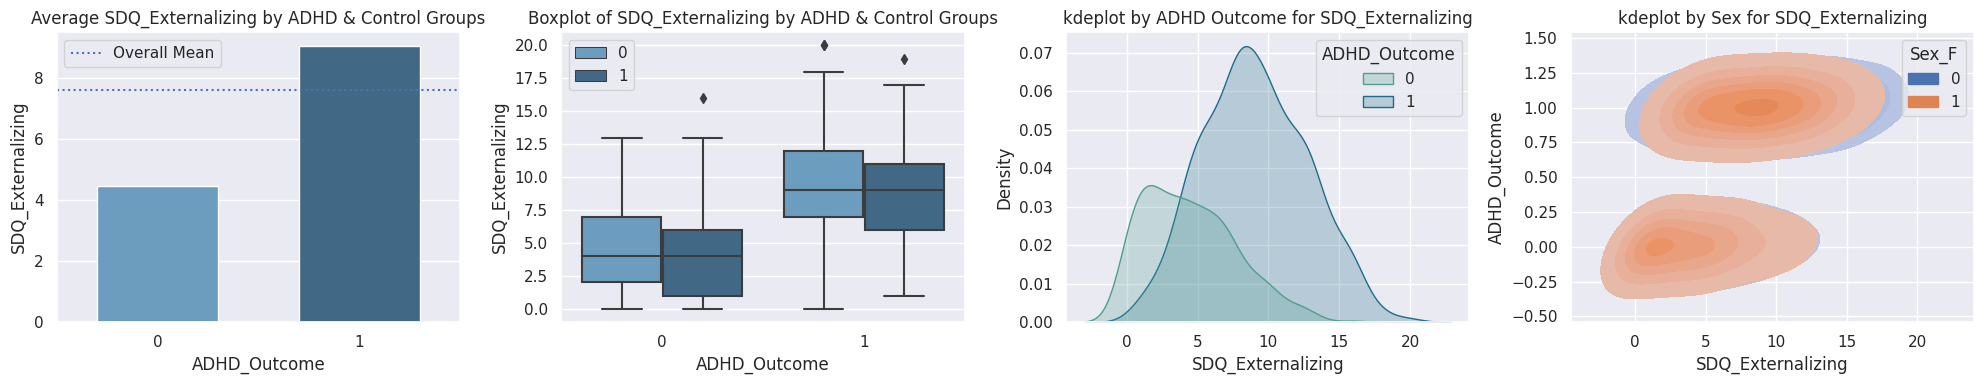

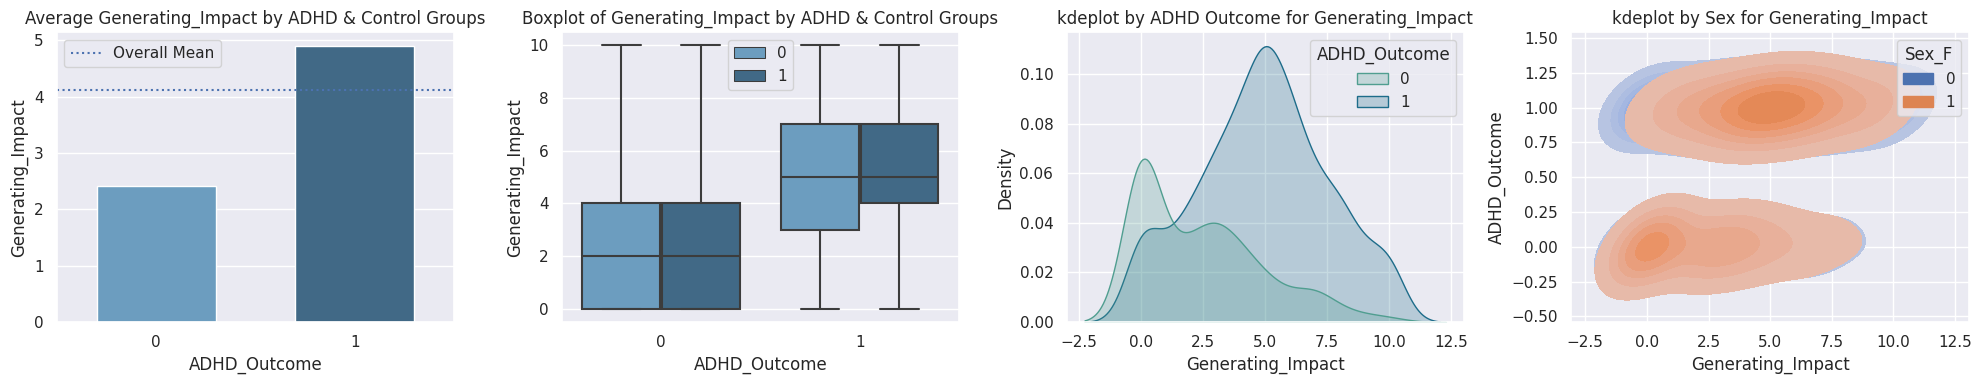

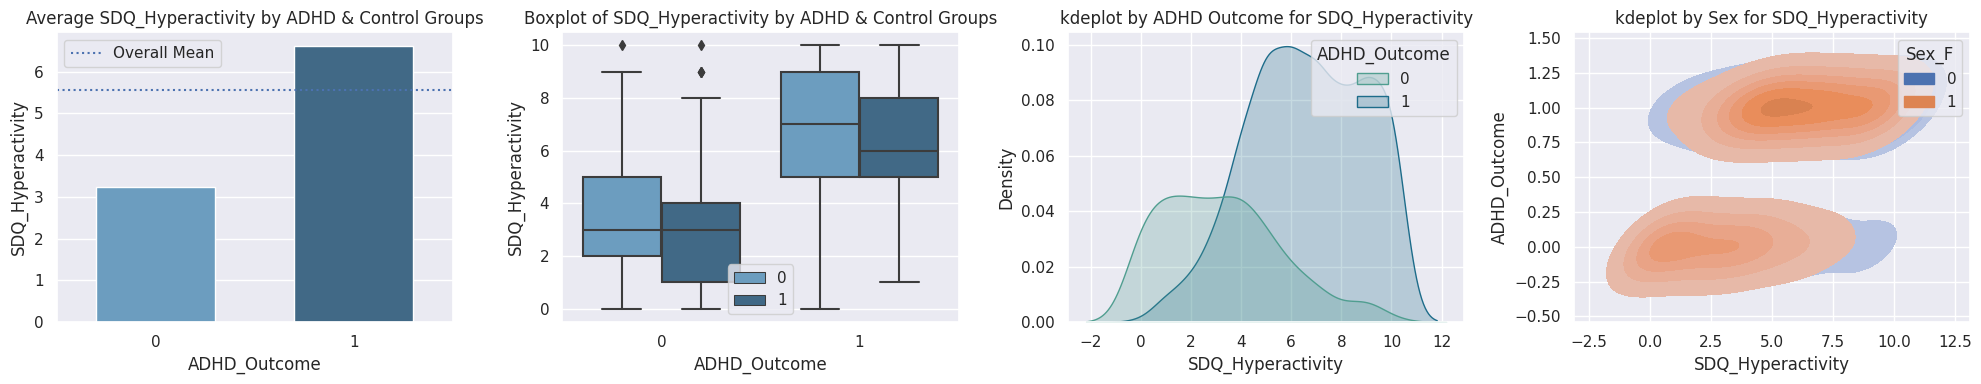

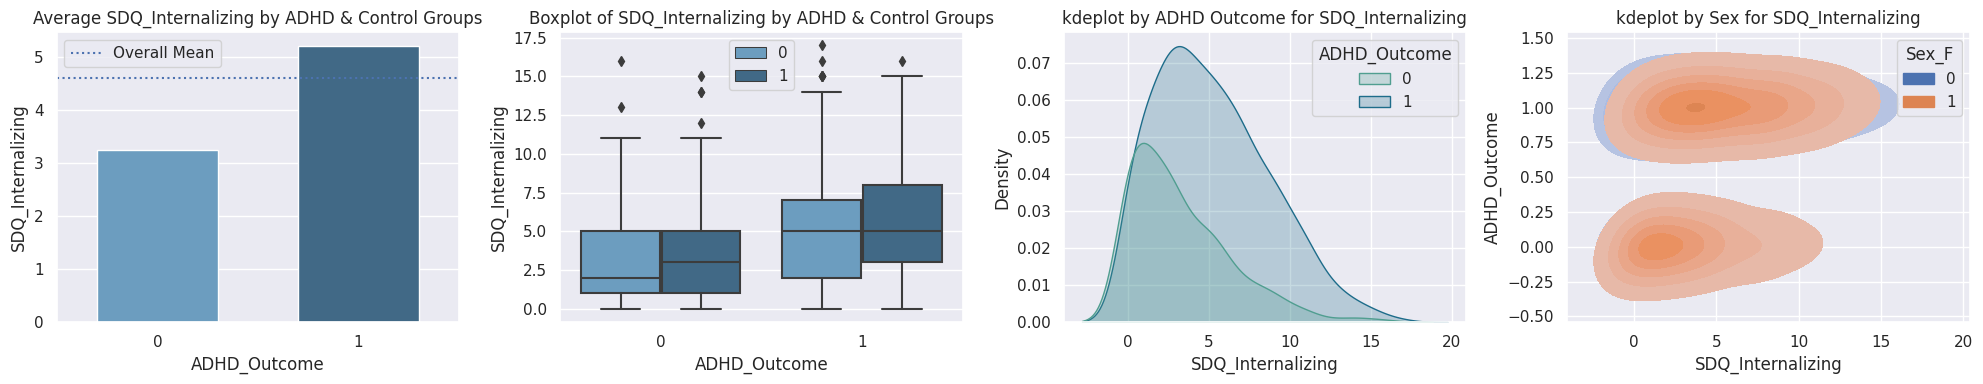

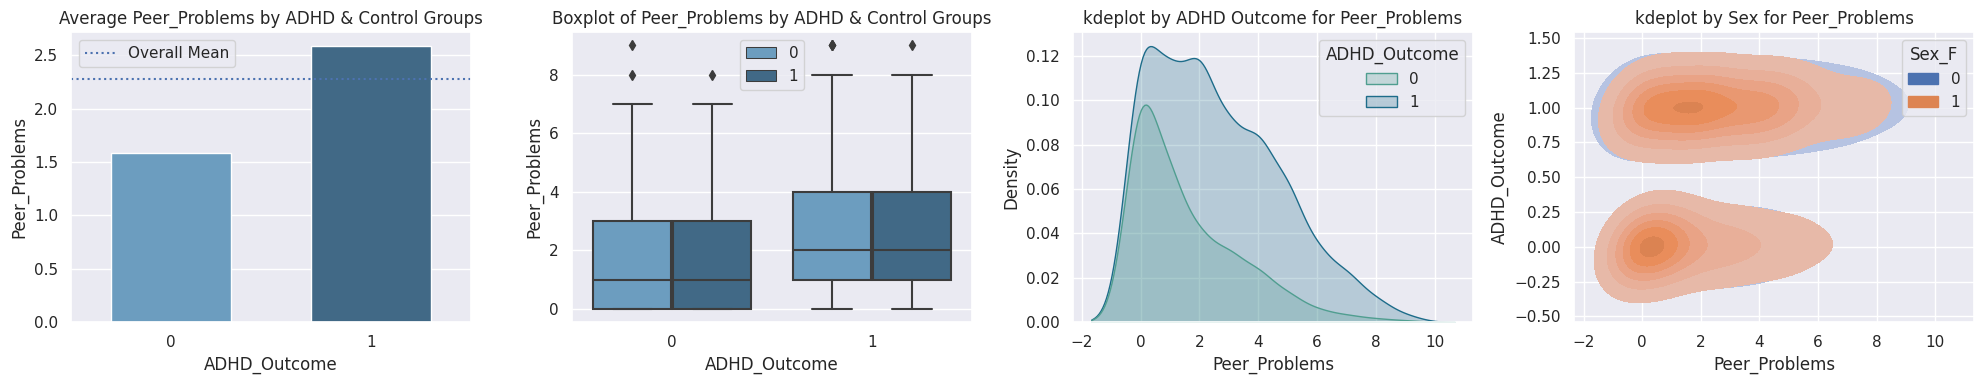

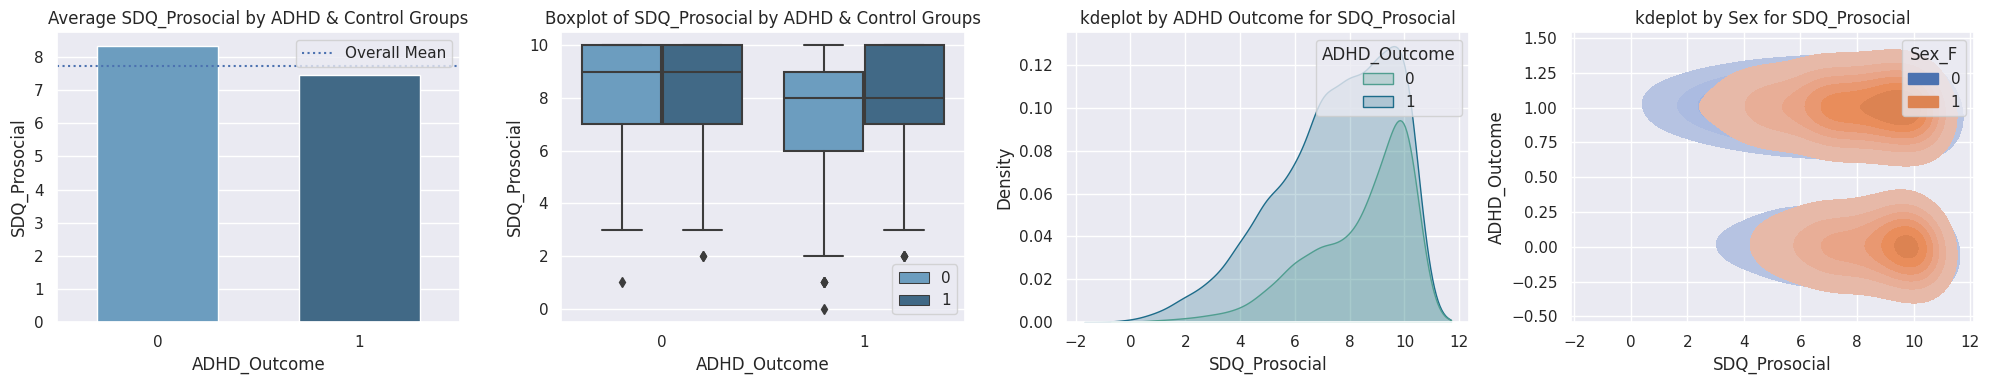

In [28]:
for i, col in enumerate(SDQ_cols):   
    fig, axes = plt.subplots(1,4, figsize=(20,4)) 
    mean_vals = mi_df.groupby(target_vars[0])[col].mean().reset_index()
    split_label = '_'.join(col.split('_')[-2:])  

    sns.barplot(data=mean_vals,
                x = target_vars[0],
                y = col,
                width=0.6,
                palette='Blues_d',
                ax=axes[0])
    axes[0].axhline(y=df[col].mean(), 
                    linestyle=':',
                    label='Overall Mean' 
                )
    axes[0].set_ylabel(split_label)   
    axes[0].legend() 
    axes[0].set_title(f"Average {split_label} by ADHD & Control Groups")     


    sns.boxplot(data=mi_df, 
                x = target_vars[0],
                y = col,
                hue = target_vars[1],
                palette='Blues_d',
                ax=axes[1])
    axes[1].set_ylabel(split_label) 
    axes[1].legend() 
    axes[1].set_title(f"Boxplot of {split_label} by ADHD & Control Groups") 

    sns.kdeplot(data=mi_df,
                x=col, 
                hue= target_vars[0],
                fill=True, 
                palette='crest', 
                ax=axes[2]) 
    axes[2].set_xlabel(split_label) 
    axes[2].set_title(f'kdeplot by ADHD Outcome for {split_label}') 

    sns.kdeplot(data=mi_df,
               x= col,
               y = target_vars[0],
               fill=True, 
               hue= target_vars[1],
               camp='mako', 
               ax=axes[3])
    axes[3].set_xlabel(split_label) 
    axes[3].set_title(f'kdeplot by Sex for {split_label}') 


    plt.tight_layout() 
    plt.show()  

### **4️⃣ Violinplot of Alabama Parenting Questionnaire (APQ)**   

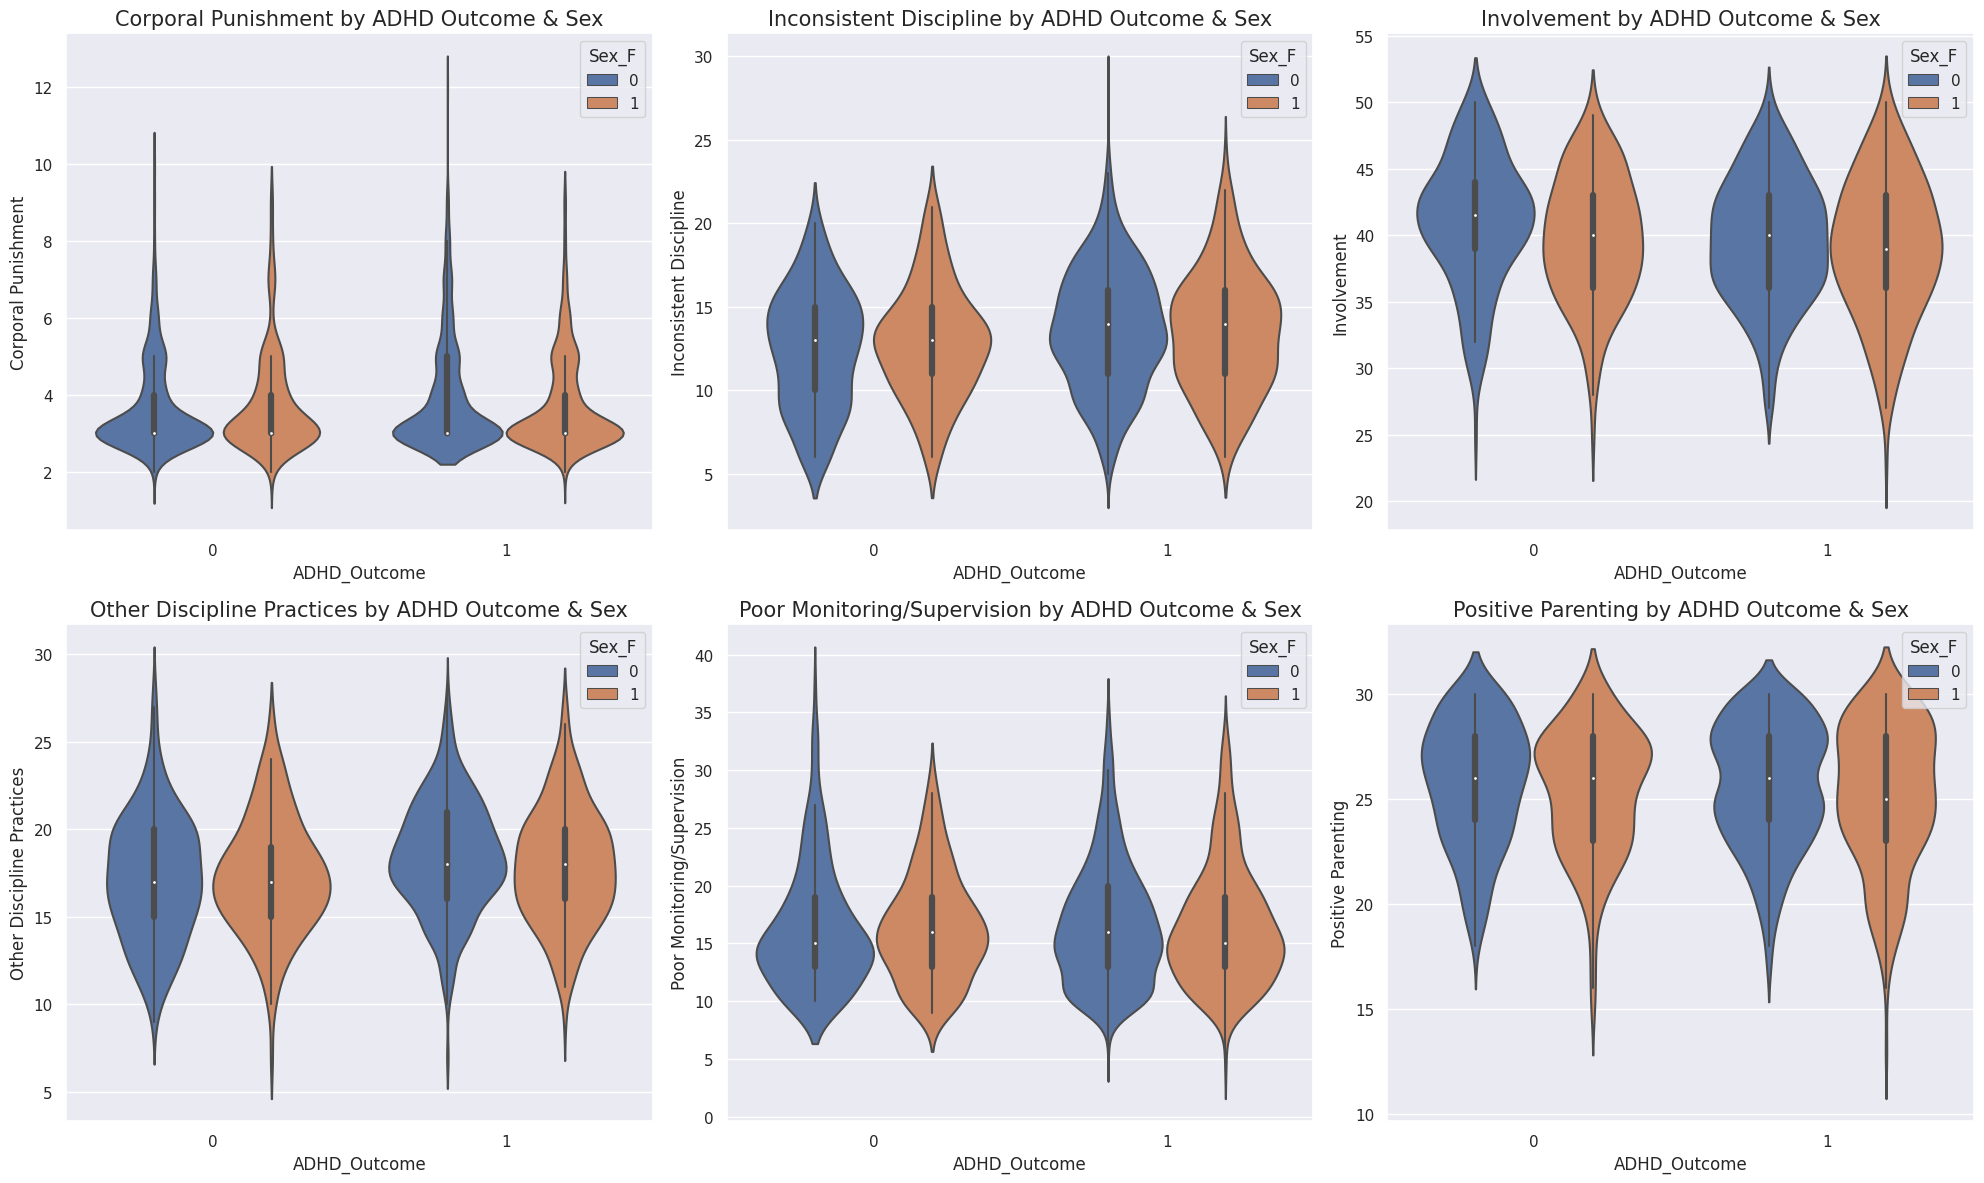

In [29]:
fig = plt.figure(figsize=(20,12))
label_map = {'APQ_P_APQ_P_CP': 'Corporal Punishment',
            'APQ_P_APQ_P_ID': 'Inconsistent Discipline',
            'APQ_P_APQ_P_INV': 'Involvement',
            'APQ_P_APQ_P_OPD': 'Other Discipline Practices',
            'APQ_P_APQ_P_PM': 'Poor Monitoring/Supervision',
            'APQ_P_APQ_P_PP': 'Positive Parenting'}
custom_labels_APQ = [label_map[idx] for idx in APQ_cols]  


for i, col in enumerate(APQ_cols):  
    plt.subplot(2,3,i+1) 
    sns.violinplot(data=mi_df,
                   x = target_vars[0],
                   y=col,
                   hue=target_vars[1],  
                  ) 
    
    plt.ylabel(custom_labels_APQ[i]) 
    plt.title(f'{custom_labels_APQ[i]} by ADHD Outcome & Sex',
             fontsize=15)  
    plt.tight_layout() 


plt.show()   

### **5️⃣Clinical Measurements**   

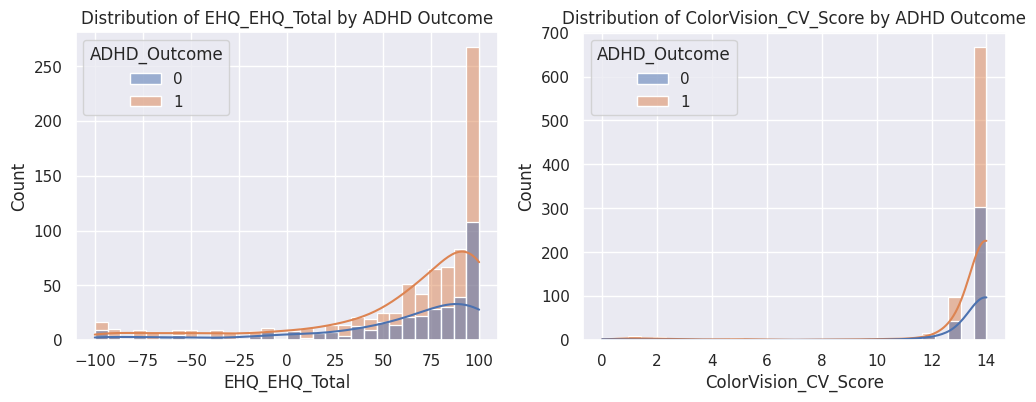

In [30]:
clinical_cols = ['EHQ_EHQ_Total', 'ColorVision_CV_Score'] 
fig = plt.figure(figsize=(12,4))

for i, col in enumerate(clinical_cols):
    plt.subplot(1,2,i+1) 
    sns.histplot(data = mi_df,
                 x = col, 
                 bins=30,
                 kde=True,
                 hue='ADHD_Outcome') 
    plt.title(f'Distribution of {col} by ADHD Outcome') 

plt.show() 

## 🧠 **Understand Functional Connectome Matrices:**

### 🔨 Methodologies:  

  * **Graph Theory (completed)**
  * **PCA + SVM (Ongoing)** 
  * **Topological Data Analysis(Ongoing)**  

In [31]:
os.listdir('/kaggle/input/functional-matrices')            

['TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv']

In [32]:
df_fcm = pd.read_csv('/kaggle/input/functional-matrices/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv') 

In [33]:
df_fcm = df_fcm.merge(df_solu, 
                      on = 'participant_id', 
                      how = 'inner')   

## 🔭 ***Data Exploration (EDA) & Preprocessing***  

### 🔍 **1. Shape of the DataFrame**

In [34]:
df_fcm.shape 

(1213, 19903)

### 🔍 **2. Take a glimpse of Data:**

In [35]:
df_fcm.head(10).T 

,0,1,2,3,4,5,6,7,8,9
participant_id,70z8Q2xdTXM3,WHWymJu6zNZi,4PAQp1M6EyAo,obEacy4Of68I,s7WzzDcmDOhF,s55ZRHrJtnlL,sId1cQF5F22m,T4CaImRntWnB,a5JFxSZjVg5i,VZnIq2hRErI5
0throw_1thcolumn,0.22293,0.614765,-0.116833,0.199688,0.227321,0.337316,0.205613,-0.190693,0.243401,0.182886
0throw_2thcolumn,0.527903,0.577255,0.458408,0.752714,0.613268,0.823123,0.514554,0.311654,0.274912,0.734523
0throw_3thcolumn,0.429966,0.496127,0.260703,0.658283,0.621447,0.733585,0.580002,0.309758,0.364787,0.286137
0throw_4thcolumn,0.060457,0.496606,0.639031,0.575096,0.562673,0.418883,0.356749,0.466017,0.252179,0.300662
...,...,...,...,...,...,...,...,...,...,...
197throw_198thcolumn,0.561864,0.607656,0.461544,0.341272,0.05585,0.569374,0.408298,0.497883,0.70818,0.567601
197throw_199thcolumn,0.47117,0.550623,0.508912,0.440313,0.119065,0.737414,0.174187,0.617897,0.247329,0.723238
198throw_199thcolumn,0.365221,0.503176,0.624232,0.558193,0.108273,0.716293,0.659205,0.555232,0.452594,0.547051
ADHD_Outcome,1,1,1,1,1,1,0,1,1,1


### 🔍 **3. Check Missing & Duplicated Values:**

In [36]:
df_fcm.isnull().sum().sum() 

0

In [37]:
df_fcm.duplicated().sum() 

0

###  **🧠 Graph Theory Meets Neuroscience -- Space, Time and Graph**   

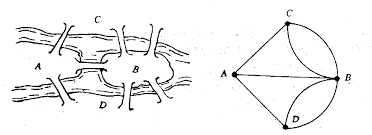
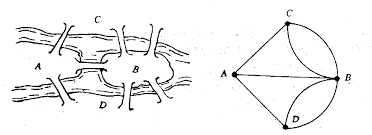

In [38]:
import networkx as nx 

# Stratified Sampling: 

def stratified_sampling(data, stratify_col='group', n_per_group=300, random_state=1844): 
    groups = data.groupby(stratify_col) 
    samples = [] 
    for group_name, group_data in groups: 
        samples.append(group_data.sample(n_per_group, 
                      random_state = random_state))   
    balanced_df = pd.concat(samples)  
    return balanced_df.reset_index(drop=True) 

balanced_df = stratified_sampling(df_fcm, 
                   stratify_col = 'ADHD_Outcome',
                   n_per_group=300,
                   random_state=1844)      

In [39]:
balanced_df.head()  

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,B96nlXiAgJGW,0.393848,0.576607,0.407809,0.491384,0.763981,0.713794,0.640433,0.464216,0.588007,...,-0.138346,0.071990,0.723404,0.380550,0.466097,0.372758,0.495154,0.532916,0,1
1,puNhkxYxMekm,0.221635,0.820028,0.801427,0.732220,0.857974,0.730591,0.806846,0.454591,0.706349,...,-0.030974,-0.088281,0.510481,0.339666,0.439844,0.724633,0.603156,0.480689,0,0
2,5nMvgEkXdeOB,-0.159775,0.501960,0.016561,0.107725,0.252008,0.631113,0.769891,0.270468,0.529121,...,-0.193510,0.192088,0.613425,0.519656,0.060962,0.534845,0.041404,0.287084,0,0
3,W1uPC9UrBXvR,0.043559,0.397722,0.677680,0.789262,0.816817,0.680458,0.654559,0.448757,0.557520,...,0.014718,-0.032436,0.852087,0.274524,0.510822,0.287906,0.561271,0.772028,0,0
4,05ocQutkURd6,0.450442,0.731530,0.799147,0.701688,0.747468,0.523304,0.575033,0.187189,0.441150,...,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613,0,1


In [40]:
# Create Graph: 
def compute_graph(row, participant_id, num_regions=200):   
    connectome_cols = [col for col in balanced_df.columns if "throw" in col]  
    connectome_vals = row[connectome_cols].values 
    matrix = np.zeros((num_regions, num_regions))  

    index = 0 
    for i in range(num_regions):
        for j in range(i+1, num_regions): 
            matrix[i,j] = connectome_vals[index]
            matrix[j,i] = connectome_vals[index] 
            index +=1 
    return matrix 




# Apply Density Threshold: 

def apply_density_threshold(matrix, density=0.15): 
    n_nodes = matrix.shape[0] 
    triu_indices = np.triu_indices(n_nodes, k=1) 
    edge_weights = matrix[triu_indices] 
    n_edges_keep = int(len(edge_weights)*density) 
    threshold_value = np.sort(edge_weights)[::-1][n_edges_keep] 
    threshold_matrix = matrix.copy() 
    threshold_matrix[threshold_matrix < threshold_value] = 0 
    np.fill_diagonal(threshold_matrix,0) 
    return threshold_matrix  



# Graph Computations: 

def calculate_graph(threshold_matrix): 
    weight_matrix = np.abs(threshold_matrix) 
    G = nx.from_numpy_array(weight_matrix)  
    G.remove_edges_from([(u, v) for u, v, d in list(G.edges(data=True)) if d['weight'] == 0]) 

    # betweenness centrality: 
    centrality = nx.betweenness_centrality(G, weight='weight', endpoints=True) 
    centrality_mean = np.mean(list(centrality.values())) 
    centrality_std = np.std(list(centrality.values())) 

    # clustering coefficirnt: 
    clustering_coef = nx.clustering(G, weight='weight') 
    clustering_mean = np.mean(list(clustering_coef.values())) 
    clustering_std = np.std(list(clustering_coef.values()))   

    
    # calculate global efficiency: 
    global_eff = nx.global_efficiency(G)

    metrics = {
        'centrality_mean' : centrality_mean, 
        'centrality_std' : centrality_std,
        'clustering_mean' : clustering_mean, 
        'clustering_std' : clustering_std, 
        'global_efficiency' : global_eff 
    } 

    return metrics   

In [41]:
if __name__ == "__main__":
   
   
    graph_metrics = [] 
    

    for index, row in balanced_df.iterrows():
        participant_id = row['participant_id'] 
        matrix = compute_graph(row, participant_id=row['participant_id'])
        threshold_matrix = apply_density_threshold(matrix) 
        metrics = calculate_graph(threshold_matrix) 
        metrics['participant_id'] = participant_id
        graph_metrics.append(metrics) 

    metrics_df = pd.DataFrame(graph_metrics)    


import gc
gc.collect()     

62335

In [42]:
metrics_df 

,centrality_mean,centrality_std,clustering_mean,clustering_std,global_efficiency,participant_id
0,0.016644,0.005727,0.302569,0.076375,0.501027,B96nlXiAgJGW
1,0.016425,0.005141,0.276377,0.083439,0.507973,puNhkxYxMekm
2,0.016061,0.004894,0.235299,0.062057,0.519523,5nMvgEkXdeOB
3,0.017168,0.006362,0.324132,0.079392,0.489272,W1uPC9UrBXvR
4,0.016377,0.005554,0.279475,0.074660,0.510268,05ocQutkURd6
...,...,...,...,...,...,...
595,0.016446,0.005869,0.270258,0.075165,0.510302,rD1V05NeFHrM
596,0.016354,0.005412,0.283748,0.072629,0.510314,pt9crzQunzLC
597,0.016192,0.004618,0.259588,0.059989,0.515645,9D4a3uKBWE1K
598,0.016169,0.004884,0.234394,0.073441,0.517203,oQIEFet6cEff


In [43]:
 merged_df = df_solu.merge(metrics_df,
                           on='participant_id',
                           how='inner')     

In [44]:
merged_df

,participant_id,ADHD_Outcome,Sex_F,centrality_mean,centrality_std,clustering_mean,clustering_std,global_efficiency
0,UmrK0vMLopoR,1,1,0.016359,0.005874,0.279950,0.095320,0.508559
1,p4vPhVu91o4b,1,1,0.015997,0.004707,0.247392,0.078469,0.526277
2,tBGXkEdv2cp7,1,0,0.015998,0.004359,0.247136,0.071253,0.521240
3,DgRP31gu21O9,1,0,0.016390,0.005182,0.273315,0.072290,0.508701
4,FrjCLpmemRKk,1,1,0.016082,0.004970,0.251650,0.082454,0.521001
...,...,...,...,...,...,...,...,...
595,8RqLpySUwmWx,0,0,0.016205,0.005529,0.279187,0.078655,0.504317
596,Zusa1n9tQ3Yb,0,1,0.016338,0.004642,0.276976,0.067913,0.512580
597,Atx7oub96GXS,0,0,0.015711,0.004304,0.211018,0.051092,0.533802
598,groSbUfkQngM,0,1,0.016509,0.005868,0.279795,0.084017,0.506599


#### **1. Betweenness Centrality:**
* ####  **It measures the proportion of the shortest paths bettween all node-pairs that pass through a given node.**
* ####  **High Proportion --> represent central element of the network --> critical for information flow**



#### **2. Clustering Coefficient:**
* ####  **It measures the probability of finding the connection between any two neighbors of node i. --> how interconnected a node's neighbors are.**
* ####  **High Values --> tightly connected local circuits --> specialized processing modules.**

#### **3. Characteristic Path Length:**
* ####  **It measures the average of shrtest path length between all pairs of nodes --> reflexts global integration/ efficiency of information transfered across the network.**
* ####  **shorter -> more efficient communication**


#### **4. Global Efficiency:**
* ####  **Average of the inverse shortest path length between all node pairs --> quantatifies how well information exchanged**

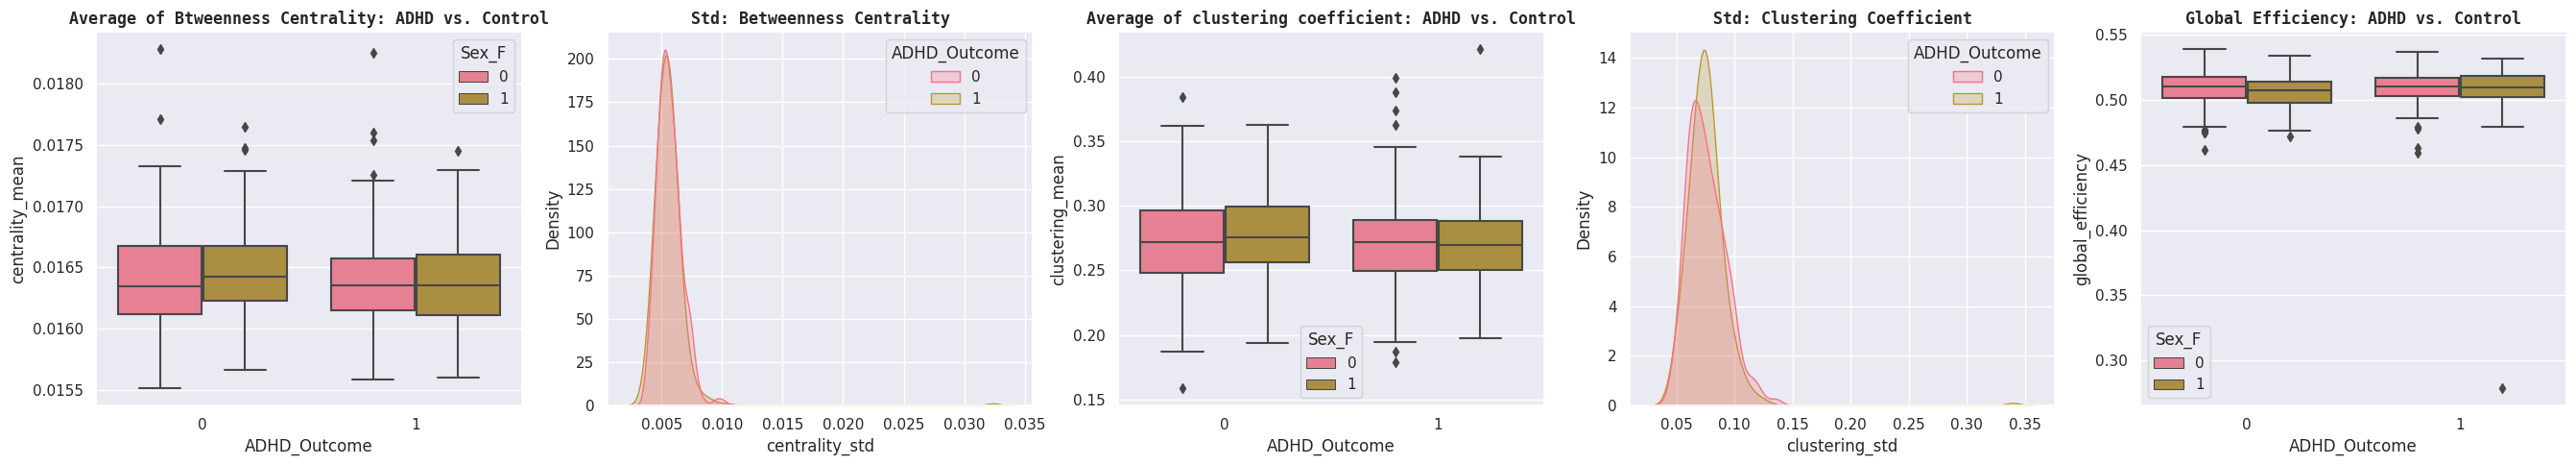

In [45]:
fig, axes = plt.subplots(1,5, figsize=(27,5))   


sns.set_palette('husl')

sns.boxplot(data=merged_df,
            y = 'centrality_mean',
            x ='ADHD_Outcome', 
            hue = 'Sex_F',
            ax=axes[0])  
axes[0].set_title("Average of Btweenness Centrality: ADHD vs. Control",
                 fontweight='bold',
                 fontfamily='monospace') 




sns.kdeplot(data= merged_df,
            x = 'centrality_std',
            hue='ADHD_Outcome', 
            fill=True,
            ax=axes[1]) 
axes[1].set_title("Std: Betweenness Centrality", 
                 fontweight='bold',
                 fontfamily='monospace')



sns.boxplot(data=merged_df,
            y = 'clustering_mean',
            x ='ADHD_Outcome', 
            hue= 'Sex_F',
            ax=axes[2])  
axes[2].set_title("Average of clustering coefficient: ADHD vs. Control",
                 fontweight='bold',
                 fontfamily='monospace') 



sns.kdeplot(data= merged_df,
            x = 'clustering_std',
            hue='ADHD_Outcome',  
            fill=True,
            ax=axes[3]) 
axes[3].set_title("Std: Clustering Coefficient", 
                 fontweight='bold',
                 fontfamily='monospace')




sns.boxplot(data=merged_df,
            y = 'global_efficiency',
            x ='ADHD_Outcome',
            hue = 'Sex_F',
            ax=axes[4]) 
axes[4].set_title("Global Efficiency: ADHD vs. Control", 
                 fontweight='bold',
                 fontfamily='monospace') 





plt.tight_layout()   
plt.show()  

In [46]:
# ANCOVA: 

def run_ancova(data, dependent_var, group_var, covariate):
   

    formula = f"{dependent_var} ~ {group_var} + " + '+'.join(covariate) 
    model = smf.ols(formula, data=data).fit() 
    ancova_table = sm.stats.anova_lm(model, typ=3)
    group_result = ancova_table.loc[group_var] 
    
    return pd.DataFrame({
        'dependent_var': dependent_var,
        'F_value': group_result['F'],
        'p_value': group_result['PR(>F)'],
        'significant': group_result['PR(>F)'] < 0.05   
    }, index=[0])    

In [47]:
graph_metrics = ['centrality_mean', 'clustering_mean', 'global_efficiency']   

In [48]:
group_var = 'ADHD_Outcome'          
covariate= ['Sex_F']  

all_results = []


for metric in graph_metrics:
    result = run_ancova(
            data=merged_df,
            dependent_var=metric,
            group_var=group_var,
            covariate=covariate 
        )
    all_results.append(result) 
    


final_results = pd.concat(all_results, ignore_index=True)


final_results = final_results.sort_values('p_value')

print("\nANCOVA:")
print(final_results.to_string(index=False)) 


ANCOVA:
    dependent_var  F_value  p_value  significant
  centrality_mean 2.426451 0.119833        False
global_efficiency 0.307311 0.579543        False
  clustering_mean 0.267698 0.605072        False


#### From the four diagrams:

1. The average betweenness centrality was slightly higher in the Control Group compared to the ADHD Group.

2. Similarly, the average clustering coefficient was a bit higher in the Control Group than in the ADHD Group. 

3. In contrast, no significant difference was observed in global efficiency between the two groups. 

4. These findings suggest that ADHD-related alterations may manifest primarily in localized brain connectivity patterns. However, a methodological limitation was the absence of standardized anatomical parcellation, which constrained me to perform region-specific analyses.  

* **Given the null findings from the graph theory analysis and the inability to perform robust region-specific metric comparisons, I pivoted to a machine learning approach.**
  
* **The original functional connectivity matrix for each subject was vectorized, resulting in a data matrix of 1213 subjects by 19900 features.**
  
* **This extreme feature-to-sample ratio poses a significant risk of overfitting for machine learning models.**

  
* **To address this high-dimensionality challenge, I employed Principal Component Analysis(PCA) for dimensionality reduction.**


* **PCA was applied to transform these features into a set of linearly uncorrelated principal components, thereby mitigating the curse of dimensionality while preserving the majority of the variance in the data for subsequent analysis.**

###  **🧠 PCA Meets fMRI Connectivity Matrices (Dimensionly Reduction)**   

In [49]:
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 

connectome_cols = [col for col in df_fcm.columns if 'throw' in col] 
X_features = df_fcm[connectome_cols].values    
meta_data = df_fcm[['participant_id', 'Sex_F', 'ADHD_Outcome']].copy()    

# Standardized: 
scaler = StandardScaler()  
X_scaled = scaler.fit_transform(X_features)   


# find the minimum number of dimensions required to preserve 95% of the variance: 
pca = PCA() 
pca.fit(X_scaled)  
cumsum = np.cumsum(pca.explained_variance_ratio_) 
d = np.argmax(cumsum >= 0.95) + 1 
print(f'Number of components for 0.95 variance: {d}') 

# run the PCA again using d:  
pca = PCA(n_components = d) 
X_reduced = pca.fit_transform(X_scaled)   
print(f'Total Explained Variance:{np.sum(pca.explained_variance_ratio_):.4f}')  

Number of components for 0.95 variance: 909
Total Explained Variance:0.9481


#### **Finding 1: A high number of dimensions (909 principal components) was required to explain 95% of the variance.**
  
#### **Interpretation:**

 **1) The variance captured by PCA encompasses between-group variance, within-group variance, and noise (e.g., motion artifacts, respiration, and scanner noise).**

  
  **2) The fact that 909 PCs were needed to capture 94.8% of the variance indicates that the underlying patterns of variability are highly dispersed.**


  **3) This finding can be inferred to reflect the inherent characteristics of ADHD itself: namely, its high heterogeneity (ADHD has three clinical presentations: predominantly inattentive, predominantly hyperactive/impulsive, and combined type).**

In [50]:
# merge: 
pc_columns = [f'PC{i+1}' for i in range(d)] 
X_reduced_df = pd.DataFrame(X_reduced, columns=pc_columns) 
df_pca = pd.concat([meta_data.reset_index(drop=True), X_reduced_df.reset_index(drop=True)],axis=1) 

In [51]:
df_pca

,participant_id,Sex_F,ADHD_Outcome,PC1,PC2,PC3,PC4,PC5,PC6,PC7,...,PC900,PC901,PC902,PC903,PC904,PC905,PC906,PC907,PC908,PC909
0,70z8Q2xdTXM3,0,1,35.753597,0.090543,-20.350098,-19.088315,-30.805000,2.306746,0.012355,...,1.759890,-0.980470,-1.000936,-1.597255,1.245672,-0.262862,0.762663,4.144016,-1.863153,1.596835
1,WHWymJu6zNZi,1,1,28.459455,-18.887916,10.232790,-1.115161,-7.235638,-14.893705,5.991655,...,0.420515,0.112593,1.758739,-1.183518,0.833481,-0.859175,2.219031,3.059000,-0.028492,-2.370297
2,4PAQp1M6EyAo,1,1,0.798687,4.718468,10.989505,17.687384,10.643912,31.792714,-9.804087,...,-0.900728,-1.467842,-2.354505,-3.073142,5.292453,2.853858,-0.848413,1.893848,1.920487,2.208413
3,obEacy4Of68I,1,1,-45.767171,-11.453186,4.095472,-12.695696,-20.976370,22.331782,4.630708,...,2.031608,-2.017276,5.180942,2.563356,2.267283,-1.277401,-1.781418,1.404469,-0.721481,1.350337
4,s7WzzDcmDOhF,1,1,3.746646,-8.847485,10.058838,2.305610,-3.341812,14.484016,28.106098,...,-3.723992,1.154242,-1.564578,-0.245556,2.187319,-1.243928,-2.939064,-2.198387,1.489000,-1.131444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,9gpepMI9sj5q,1,0,57.701748,10.744244,67.975282,9.120309,10.753183,10.431773,-1.245443,...,-4.091747,1.893973,-0.047924,0.644542,0.355423,-0.588065,3.247115,-1.684800,-0.911199,-0.794100
1209,FIDen5rdMc0v,0,1,40.413668,-4.309101,-6.565262,28.863521,-35.341576,7.694689,-2.221348,...,0.486917,1.450559,1.525064,2.838719,-0.591018,-0.021988,0.092168,-1.944880,-2.304988,0.067068
1210,dlsMC4TXL4e8,0,1,51.401497,11.874010,-3.790918,-2.594981,-1.975802,8.665818,5.950896,...,-0.691178,0.729765,-1.380454,0.411723,-0.886523,0.298105,0.597928,1.027262,0.294289,0.269195
1211,syeyZjEx8FUx,1,0,0.901549,-39.452641,-9.379260,-2.254562,-19.671686,-26.762498,7.406927,...,1.018036,3.575804,1.629163,-0.690281,-4.235065,0.355275,0.385507,-0.487927,-0.393460,0.405726


Text(0.5, 1.0, 'PCA of Brain Connectivity by ADHD Status')

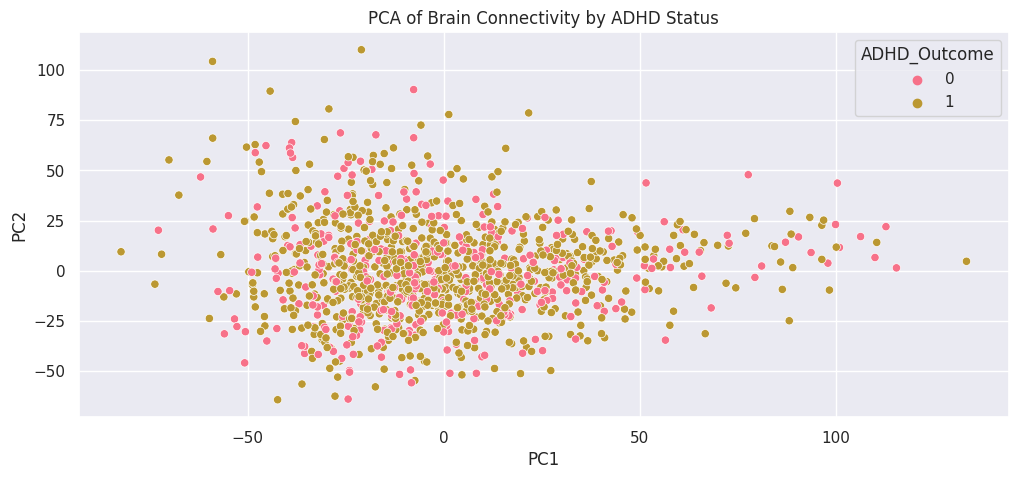

In [52]:
plt.figure(figsize=(12, 5))

sns.scatterplot(data=df_pca, 
                x='PC1', 
                y='PC2', 
                hue='ADHD_Outcome')  

plt.title('PCA of Brain Connectivity by ADHD Status')  

#### **Finding 2: The scatter plot of PC1 against PC2 failed to separate ADHD from Control groups.** 

#### **Interpretation:**

1) PC1 and PC2 capture the directions of maximum variance in the data, and PCA is an unsupervised dimensionality reduction technique.
2) It can therefore be deduced that the largest sources of variance (PC1 and PC2) likely stem from confounding factors rather than biological signals of interest, such as head motion or physiological noise (e.g., respiration).
3) Consequently, visualization based solely on the first two principal components is insufficient for classifying ADHD and Control groups.

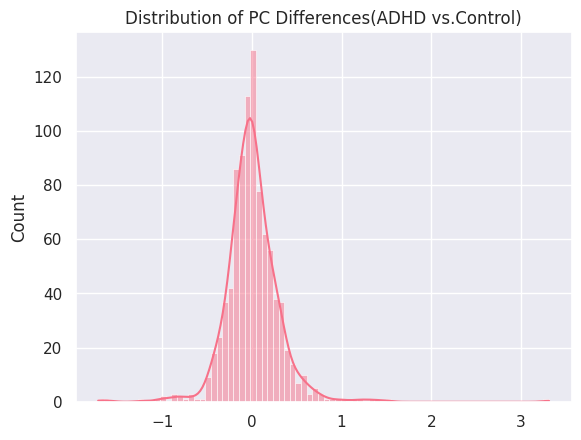

In [53]:
adhd_group = df_pca[df_pca['ADHD_Outcome']==1] 
ctrl_group = df_pca[df_pca['ADHD_Outcome']==0]  

adhd_means = adhd_group[pc_columns].mean() 
ctrl_means = ctrl_group[pc_columns].mean() 
diff = adhd_means - ctrl_means 

sns.histplot(data=diff, 
             bins=80,
             kde=True)  

plt.title('Distribution of PC Differences(ADHD vs.Control)')    
plt.show()   

In [54]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection 

p_values = []
cohen_d_values = [] 
pc_names = []  

# independent-t-test and Cohen's d  
for pc in df_pca.columns[3:]:  
    t,p = stats.ttest_ind(adhd_group[pc], ctrl_group[pc])   
    n1,n2 = len(adhd_group[pc]) , len(ctrl_group[pc]) 
    pooled_std = np.sqrt(((n1-1)*np.std(adhd_group[pc], ddof=1)**2 + (n2-1)*np.std(ctrl_group[pc], ddof=1)**2) / (n1+n2-2))
    cohen_d = (np.mean(adhd_group[pc])-np.mean(ctrl_group[pc]))/ pooled_std 

    p_values.append(p) 
    cohen_d_values.append(cohen_d) 
    pc_names.append(pc)  


# FDR: 
rejected, corrected_p_values = fdrcorrection(p_values) 
significant_pcs = np.where(rejected)[0] + 1  
print(f'Significant PCs after FDR correction: {significant_pcs}')   

p_values = np.array(p_values)
cohen_d_values = np.array(cohen_d_values)


results_df = pd.DataFrame({
    'Component': pc_names,
    'p_value': p_values,
    'Cohen_d': cohen_d_values
}) 

Significant PCs after FDR correction: []


### **Support Vector Machine(SVM) -- Gaussian Kernel**

In [55]:
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import LinearSVC 
from sklearn.model_selection import train_test_split, GridSearchCV


pc_columns_400 = [f'PC{i}' for i in range(1,401)]
X = df_pca[pc_columns_400]   
y = df_pca['ADHD_Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1904, stratify=y)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf'))
     ]) 

param_grid = {
    'svm_clf__C': [0.1, 1, 10, 100],
    'svm_clf__gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'svm_clf__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator= svm_pipeline, 
    param_grid = param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [56]:
grid_search.fit(X_train,y_train)
print(f'Best para: {grid_search.best_params_}')
print(f'Best cross-validation score: {grid_search.best_score_: .3f}')

Best para: {'svm_clf__C': 1, 'svm_clf__class_weight': 'balanced', 'svm_clf__gamma': 'scale'}
Best cross-validation score:  0.603


In [57]:
best_model = grid_search.best_estimator_ 
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy:.3f}') 

Test Accuracy: 0.671


In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.47      0.30      0.37        77
           1       0.72      0.84      0.78       166

    accuracy                           0.67       243
   macro avg       0.60      0.57      0.57       243
weighted avg       0.64      0.67      0.65       243



### **📝 Analysis of the Classification Report and Subsequent Improvements:**  

1. **Class Imbalance**
   * Analysis: The dataset is significantly imbalanced (ADHD vs. Control = 69:31), which likely biased the model towards the majority class, resulting in poor performance on the Control group.
   * Solution: Apply undersampling to the ADHD group to create a balanced training set.


     
2. **High Heterogeneity of ADHD and Weak Distributed Signal**
   * Solution: Perform unsupervised clustering analysis (e.g., K-means) on the ADHD cohort within the PCA space to investigate whether data-driven subtypes exist.


     
3. **Suboptimal Feature Selection**
   * Analysis: Using the top 400 Principal Components (PCs) based solely on variance explained is a suboptimal strategy.
   * Solution: Employ Recursive Feature Elimination (RFE) with cross-validation to perform supervised feature selection.

   
4. **Model Selection/Generalization**
   * Solution: Evaluate and compare the performance of other machine learning models that are robust to high-dimensional data, such as Random Forest and XGBoost.